## 프로젝트
### 프로젝트 제출 루브릭

|평가문항|상세기준|
|-|-|
|<br>1. tfrecord를 활용한 데이터셋 구성과 전처리를 통해 프로젝트<br> 베이스라인 구성을 확인하였다.<br><br>|	MPII 데이터셋을 기반으로 1epoch에 30분 이내에 학습가능한<br> 베이스라인을 구축하였다.|
|<br>2. simplebaseline 모델을 정상적으로 구현하였다.<br><br>|simplebaseline 모델을 구현하여 실습코드의 모델을 대체하여<br> 정상적으로 학습이 진행되었다.|
|<br>3. Hourglass 모델과 simplebaseline 모델을 비교분석한 결과를<br> 체계적으로 정리하였다.<br><br>|두 모델의 pose estimation 테스트결과 이미지 및 학습진행상황 등을<br> 체계적으로 비교분석하였다.|

## Ablation Study 1: StackedHourglassNetwork vs. Simplebaseline

이 연구는 두 가지 포즈 추정 모델인 `StackedHourglassNetwork`와 `Simplebaseline` 모델의 성능을 비교하는 것을 목표로 합니다.

### 목표:
1.  **`Simplebaseline` 모델 구현**: `Simplebaseline` 모델 구현을 완료합니다.
2.  **두 모델 훈련**: `StackedHourglassNetwork`와 `Simplebaseline` 두 모델 모두 MPII 데이터셋으로 지정된 에포크 수(최소 3회, 5회 권장)만큼 훈련합니다.
3.  **결과 비교**: 다음을 사용하여 두 모델의 성능을 분석하고 비교합니다.
    *   **정성적 비교**: 두 모델에 대한 일반적인 테스트 이미지에서 포즈 추정 결과를 시각화합니다.
    *   **정량적 비교**: 두 모델의 에포크별 훈련 및 검증 손실 곡선을 검토합니다.

### 실행 단계:
*   `Simplebaseline` 모델이 올바르게 구현되었는지 확인합니다.
*   `StackedHourglassNetwork`와 `Simplebaseline` 두 모델을 훈련합니다. 이 셀은 최상의 모델과 훈련 기록을 Google Drive에 저장합니다.
*   두 모델을 사용하여 테스트 이미지에 대한 포즈 추정 결과를 시각화합니다.
*   두 모델의 훈련 및 검증 손실 곡선을 플로팅하고 비교합니다.

In [142]:
import os
from google.colab import drive

# 구글 드라이브 마운트
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **23. 행동 스티커 만들기**

## **23-1. 들어가며**

### **MPII 데이터셋 다운로드하기**
---

오늘은 MPII Human Pose Dataset을 사용해서 Human Pose Estimation task를 위한 모델을 훈련시켜 보겠습니다.

http://human-pose.mpi-inf.mpg.de/#download

> (주의) mpii_human_pose_v1.tar.gz 파일은 무려 12GB가 넘는 용량을 가지고 있습니다. 공식 홈페이지에서 다운로드시 수 시간이 소요될 수 있으므로 학습전 미리 다운로드해 두시기를 권합니다.

In [143]:
!sudo apt install unzip -y
os.makedirs('./aiffel/mpii', exist_ok=True)

# tar.gz 파일 다운로드 확인
if not os.path.exists('./aiffel/mpii/mpii_human_pose_v1.tar.gz'):
    !wget -c https://datasets.d2.mpi-inf.mpg.de/andriluka14cvpr/mpii_human_pose_v1.tar.gz -P ./aiffel/mpii
else:
    print("mpii_human_pose_v1.tar.gz 파일이 이미 존재합니다.")

# zip 파일 다운로드 확인
if not os.path.exists('./aiffel/mpii/mpii_human_pose_v1_u12_2.zip'):
    !wget -c https://datasets.d2.mpi-inf.mpg.de/andriluka14cvpr/mpii_human_pose_v1_u12_2.zip -P ./aiffel/mpii
else:
    print("mpii_human_pose_v1_u12_2.zip 파일이 이미 존재합니다.")

# tar 파일 압축 해제 확인 (images 폴더 존재 여부로 확인)
if not os.path.exists('./aiffel/mpii/images'):
    print("tar 파일 압축 해제 중...")
    !tar -xf ./aiffel/mpii/mpii_human_pose_v1.tar.gz -C ./aiffel/mpii
else:
    print("tar 파일이 이미 압축 해제되어 있습니다.")

# zip 파일 압축 해제 확인 (mpii_human_pose_v1_u12_2 폴더 존재 여부로 확인)
if not os.path.exists('./aiffel/mpii/mpii_human_pose_v1_u12_2'):
    print("zip 파일 압축 해제 중...")
    !unzip -q -n ./aiffel/mpii/mpii_human_pose_v1_u12_2.zip -d ./aiffel/mpii
else:
    print("zip 파일이 이미 압축 해제되어 있습니다.")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unzip is already the newest version (6.0-26ubuntu3.2).
0 upgraded, 0 newly installed, 0 to remove and 57 not upgraded.
mpii_human_pose_v1.tar.gz 파일이 이미 존재합니다.
mpii_human_pose_v1_u12_2.zip 파일이 이미 존재합니다.
tar 파일이 이미 압축 해제되어 있습니다.
zip 파일이 이미 압축 해제되어 있습니다.


`mpii_human_pose_v1_u12_2.zip` 을 풀어보면 `mpii_human_pose_v1_u12_1.mat` 파일이 나와서 열어보기 불편한데요. 파이썬에서 읽기 쉽도록 json 파일로 변환해 두었습니다.

In [144]:
import os

target_dir = './aiffel/mpii/mpii_human_pose_v1_u12_2'
os.makedirs(target_dir, exist_ok=True)

# train.json 다운로드 확인
if not os.path.exists(os.path.join(target_dir, 'train.json')):
    !wget -c https://d3s0tskafalll9.cloudfront.net/media/documents/train.json -P {target_dir}
else:
    print("train.json 파일이 이미 존재합니다.")

# validation.json 다운로드 확인
if not os.path.exists(os.path.join(target_dir, 'validation.json')):
    !wget -c https://d3s0tskafalll9.cloudfront.net/media/documents/validation.json -P {target_dir}
else:
    print("validation.json 파일이 이미 존재합니다.")


train.json 파일이 이미 존재합니다.
validation.json 파일이 이미 존재합니다.


## **23-2. 데이터 전처리하기**

우선 필요한 패키지를 설치해 주세요.

In [145]:
try:
    import ray
    print("ray 패키지가 이미 설치되어 있습니다.")
except ImportError:
    print("ray 패키지가 없습니다. 설치를 진행합니다...")
    !pip install ray


ray 패키지가 이미 설치되어 있습니다.


앞으로 사용할 라이브러리를 불러옵니다. 고정해서 사용할 변수도 만들어 두죠.

In [146]:
# 주의! ray를 pytorch보다 먼저 import하면 오류가 발생할 수 있습니다
import io, json, os, math

import torch
import torch.nn as nn
import torch.nn.functional as F

import ray

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# 프로젝트 경로 설정
PROJECT_PATH = './aiffel/mpii'
IMAGE_PATH = os.path.join(PROJECT_PATH, 'images')
MODEL_PATH = os.path.join(PROJECT_PATH, 'models')
PT_RECORD_PATH = os.path.join(PROJECT_PATH, 'ptrecords_mpii')
TRAIN_JSON = os.path.join(PROJECT_PATH, 'mpii_human_pose_v1_u12_2', 'train.json')
VALID_JSON = os.path.join(PROJECT_PATH, 'mpii_human_pose_v1_u12_2', 'validation.json')

# --- CONFIGURATION for Training and Model --- #
CONFIG = {
    'epochs': 3,  # 루브릭 기준 최소 3, 권장 5 Epoch 이상
    'learning_rate': 0.0007,
    'num_heatmap': 16,
    'batch_size': 16,
    'image_shape': (256, 256, 3), # (height, width, channels)
    'heatmap_size': (64, 64),     # (height, width)
    'hourglass_num_stack': 4,
    'hourglass_num_residual': 1,
}

print('슝=3')

슝=3


### **json 파싱하기**

이전 스텝에서 `train.json`과 `validation.json` 파일이 소개된 것을 기억하시나요? 이 파일들은 이미지에 담겨 있는 사람들의 pose keypoint 정보들을 가지고 있어서 Pose Estimation을 위한 label로 삼을 수 있습니다. \
\
우선 json이 어떻게 구성되어 있는지 파악해 보기 위해 json 파일을 열어 샘플로 annotation 정보를 1개만 출력해 봅시다. `json.dumps()`를 활용해서 좀 더 명확하게 하면 더욱 좋습니다.

In [147]:
with open(TRAIN_JSON) as train_json:
    train_annos = json.load(train_json)
    json_formatted_str = json.dumps(train_annos[0], indent=2)
    print(json_formatted_str)

{
  "joints_vis": [
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1,
    1
  ],
  "joints": [
    [
      620.0,
      394.0
    ],
    [
      616.0,
      269.0
    ],
    [
      573.0,
      185.0
    ],
    [
      647.0,
      188.0
    ],
    [
      661.0,
      221.0
    ],
    [
      656.0,
      231.0
    ],
    [
      610.0,
      187.0
    ],
    [
      647.0,
      176.0
    ],
    [
      637.0201,
      189.8183
    ],
    [
      695.9799,
      108.1817
    ],
    [
      606.0,
      217.0
    ],
    [
      553.0,
      161.0
    ],
    [
      601.0,
      167.0
    ],
    [
      692.0,
      185.0
    ],
    [
      693.0,
      240.0
    ],
    [
      688.0,
      313.0
    ]
  ],
  "image": "015601864.jpg",
  "scale": 3.021046,
  "center": [
    594.0,
    257.0
  ]
}


`joints` 가 우리가 label 로 사용할 keypoint 의 label 입니다. 이미지 형상과 사람의 포즈에 따라 모든 label 이 이미지에 나타나지 않기 때문에 `joints_vis` 를 이용해서 실제로 사용할 수 있는 keypoint 인지 나타냅니다. MPII 의 경우 1 (visible) / 0(non) 으로만 나누어지기 때문에 조금 더 쉽게 사용할 수 있습니다. coco 의 경우 2 / 1 / 0 으로 표현해서 occlusion 상황까지 label 화 되어 있습니다. \
\
`joints` 순서는 아래와 같은 순서로 배치되어 저장해 뒀습니다.

* 0 - 오른쪽 발목
* 1 - 오른쪽 무릎
* 2 - 오른쪽 엉덩이
* 3 - 왼쪽 엉덩이
* 4 - 왼쪽 무릎
* 5 - 왼쪽 발목
* 6 - 골반
* 7 - 가슴(흉부)
* 8 - 목
* 9 - 머리 위
* 10 - 오른쪽 손목
* 11 - 오른쪽 팔꿈치
* 12 - 오른쪽 어깨
* 13 - 왼쪽 어깨
* 14 - 왼쪽 팔꿈치
* 15 - 왼쪽 손목

`scale`과 `center`는 사람 몸의 크기와 중심점 입니다. `scale`은 200을 곱해야 온전한 크기가 됩니다. 추후에 전처리 과정에서 200을 곱해서 사용할 예정이에요. \
\
이제 json annotation 을 파싱하는 함수를 만들어 보겠습니다.

In [148]:
def parse_one_annotation(anno, image_dir):
    filename = anno['image']
    joints = anno['joints']
    joints_visibility = anno['joints_vis']
    annotation = {
        'filename': filename,
        'filepath': os.path.join(image_dir, filename),
        'joints_visibility': joints_visibility,
        'joints': joints,
        'center': anno['center'],
        'scale' : anno['scale']
    }
    return annotation

print('슝=3')

슝=3


한 번 `parse_one_annotation()`함수를 테스트 해봅시다.

In [149]:
with open(TRAIN_JSON) as train_json:
    train_annos = json.load(train_json)
    test = parse_one_annotation(train_annos[0], IMAGE_PATH)
    print(test)

{'filename': '015601864.jpg', 'filepath': './aiffel/mpii/images/015601864.jpg', 'joints_visibility': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'joints': [[620.0, 394.0], [616.0, 269.0], [573.0, 185.0], [647.0, 188.0], [661.0, 221.0], [656.0, 231.0], [610.0, 187.0], [647.0, 176.0], [637.0201, 189.8183], [695.9799, 108.1817], [606.0, 217.0], [553.0, 161.0], [601.0, 167.0], [692.0, 185.0], [693.0, 240.0], [688.0, 313.0]], 'center': [594.0, 257.0], 'scale': 3.021046}


이제 우리가 원하는 정보만 뽑아낼 수 있게 되었네요. 다음으로 넘어가보죠.

## **23-3. DataLoader 파일 만들기**

### **DataLoader 파일 만들기**

이전까지는 tf.keras 의 `ImageDataGenerator` 를 이용해서 주로 학습 데이터를 읽었습니다. 하지만 실제 프로젝트에서는 튜토리얼 데이터셋보다 훨씬 큰 크기의 데이터를 다뤄야 합니다. \
\
학습을 많이 해볼수록 학습 속도에 관심을 가지게 되는데요.

<br>일반적으로 학습 과정에서 gpu 의 연산 속도보다 HDD I/O 가 느리기 때문에 병목 현상이 발생하고 대단위 프로젝트 실험에서 효율성이 떨어지는 것을 관찰할 수 있습니다. (답답해요..) \
\
따라서 "학습 데이터를 어떻게 빠르게 읽는가?" 에 대한 고민을 반드시 수행하셔야 더 많은 실험을 할 수 있습니다. \
\
다음 링크를 보고 퀴즈를 풀어 봅시다.<br><br>

* [`torch.utils.data.DataLoader`로 성능 향상하기](https://pytorch.org/docs/stable/data.html)

내용이 꽤 어렵습니다만 PyTorch 에서는 위 변환을 자동화해주는 도구를 제공합니다. 데이터셋을 DataLoader 형태로 표현하는 것인데요. DataLoader 는 binary record sequence 를 저장하기 위한 형식입니다. \
\
내부적으로 protocol buffer 라는 것을 이용합니다.<br><br>

* https://developers.google.com/protocol-buffers/?hl=ko

<br>protocol buffer 는 크로스 플랫폼에서 사용할 수 있는 직렬화 데이터 라이브러리라고 생각하시면 됩니다. \
\
데이터를 직렬화 한다는 것은 의미가 있는 정보만 추출해 나열하는 것을 뜻합니다. 예를 들어 "서울 강동구에 사는 32살 고길동"님을 나타내기 위해 "서울강동32고길동"과 같이 쓴다면 데이터만 담을 수 있겠죠? 다만 데이터 형식을 고정해야 하기 때문에 첫 두 글자는 시를 뜻하고, 다음 두 글자는 구를 뜻하고 다음 두 자리 숫자가 오고 이름은 세 글자여야 하는 제한이 생깁니다. 100살이 넘는 사람이나 이름이 세 글자가 아닌 사람을 담을 수 없어요. 그래서 매우 정형화된 데이터는 직렬화 하면 데이터 크기와 처리 속도 측면에서 유리하지만 사용하는데 제한이 있다고 기억하면 좋습니다. 어떤 데이터에서 어떤 방법으로 직렬화를 수행할지에 따라 발생되는 제한이 달라질 수도 있고요. \
\
이제 구현을 시작하겠습니다. 하나하나 천천히 가보죠. 앞서 추출한 annotation을 `.pt`로 변환하는 함수를 만들게요.

In [150]:
def generate_ptexample(anno):
    filename = anno['filename']
    filepath = anno['filepath']

    # 이미지 파일 읽기
    with open(filepath, 'rb') as image_file:
        content = image_file.read()

    image = Image.open(filepath)
    # JPEG 형식 및 RGB 모드가 아니면 변환
    if image.format != 'JPEG' or image.mode != 'RGB':
        image_rgb = image.convert('RGB')
        with io.BytesIO() as output:
            image_rgb.save(output, format="JPEG", quality=95)
            content = output.getvalue()

    width, height = image.size
    depth = 3

    c_x = int(anno['center'][0])
    c_y = int(anno['center'][1])
    scale = anno['scale']

    # [검수 수정] 원본은 x/y 모두 `if X else X`로 무의미했고,
    # 특히 y의 else 분기가 joint[0](=x)을 반환하는 버그가 있었습니다.
    # keypoint 좌표는 음수(-1: invisible)도 그대로 보존해야 하므로 단순히 정수 변환만 합니다.
    x = [int(joint[0]) for joint in anno['joints']]
    y = [int(joint[1]) for joint in anno['joints']]

    v = [0 if joint_v == 0 else 2 for joint_v in anno['joints_visibility']]

    feature = {
        'image/height': height,
        'image/width': width,
        'image/depth': depth,
        'image/object/parts/x': x,
        'image/object/parts/y': y,
        'image/object/center/x': c_x,
        'image/object/center/y': c_y,
        'image/object/scale': scale,
        'image/object/parts/v': v,
        'image/encoded': content,
        'image/filename': filename.encode()  # bytes로 저장
    }

    return feature

print('슝=3')

슝=3


하나의 annotation이 `generate_ptexample()`을 통해 PyTorch 형식으로 변환되었다면, 이제 여러 annotation을 한 번에 처리할 수 있도록 함수를 만들어야 합니다. \
\
여기서는 하나의 `.pt` 파일을 만들지 않고, 여러 개로 나누어 저장할 예정입니다.
먼저, 얼마나 많은 `.pt` 파일을 생성할지 결정하는 함수를 만들어 보겠습니다.

In [151]:
def chunkify(l, n):
    size = len(l) // n
    start = 0
    results = []
    for i in range(n):
        results.append(l[start:start + size])
        start += size
    return results

print('슝=3')

슝=3


이 함수는 전체 데이터를 여러 개의 그룹으로 나누는 역할을 합니다. 전체 데이터를 `n`개의 그룹으로 나눈 후, 결과적으로 `n`개의 .pt 파일을 생성하게 됩니다. \
\
여기서 좀 더 전문적으로는 이를 **sharding**이라고 합니다. 대규모 데이터셋을 여러 개의 작은 파일로 나누어 저장하는 방식입니다. 이렇게 하면 데이터 저장이 용이할 뿐만 아니라, PyTorch의 `DataLoader`를 사용할 때 여러 파일을 동시에 로드하여 학습 속도를 향상시킬 수 있습니다. \
\
이 때, 이 데이터는 원래 하나의 큰 데이터였기 때문에 저장 후 어떻게 사용할 것인가에 따라서 sharding 전략이 달라지는데요. 그 내용을 다루기에는 너무 방대하니 여기서는 간단히만 다룹니다. 모델을 학습하는데 각 파일의 크기와 개수만 고려해보면, 너무 작은 파일로 많이 나누는 것도, 너무 큰 파일로 적게 나누는 것도 좋지 않습니다. 너무 작은 파일로 많이 나누면 학습 중간에 너무 잦은 입출력이 요구되고, 너무 큰 파일로 적게 나누면 입출력마다 걸리는 시간이 길어집니다. 입출력에 걸리는 시간이 GPU의 계산 시간보다 길어지면 그만큼 손해가 됩니다. 적절한 파일 크기와 개수는 케바케라고 할 수 있어요.<br><br>

* [torch.utils.data](https://pytorch.org/docs/stable/data.html)

설명은 어렵지만 실행해보면 단순합니다. 그럼 `chunkify`함수를 테스트 해볼까요?

In [152]:
test_chunks = chunkify([0] * 1000, 64)
print(test_chunks)
print(len(test_chunks))
print(len(test_chunks[0]))

[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0,

0이 1000개 들어 있는 리스트가 64개로 쪼개졌네요. `chunkify` 함수를 테스트 해봤으니 하나의 chunk를 `.pt`로 만들어 줄 함수를 만듭시다.

In [153]:
import pickle

@ray.remote
def build_single_ptrecord(chunk, path):
    print('start to build ptrecord for ' + path)

    with open(path, 'wb') as writer:
        for anno in chunk:
            ptexample = generate_ptexample(anno)
            pickle.dump(ptexample, writer)

    print('finished building ptrecord for ' + path)

print('슝=3')

슝=3


`chunk`안에는 여러 annotation들이 있고, annotation들은 `generate_ptexample()`로 변환된 후에 문자열로 직렬화되어 `.pt` 파일에 담기는군요. \
\
또 한 가지 주의해서 봐야할 것은 함수 정의 위에 `@ray.remote`가 있다는 점이예요.<br><br>

* [RAY](https://www.ray.io/)

<br>Ray는 병렬 처리를 위한 라이브러리인데요. 파이썬에서 기본적으로 제공하는 multiprocessing 패키지보다 편하게 다양한 환경에서 사용할 수 있습니다. \
\
이제 모든 준비가 되었으니 전체 데이터를 적당한 수의 `.pt` 파일로 만들어주는 함수를 만듭시다. ray를 사용하기 때문에 함수를 호출하는 문법이 약간 다르다는 점에 주의하세요.

In [154]:
def build_pt_records(annotations, total_shards, split):
    chunks = chunkify(annotations, total_shards)
    futures = [
        build_single_ptrecord.remote(
            chunk, '{}/{}_{}_of_{}.ptrecords'.format(
                PT_RECORD_PATH,
                split,
                str(i + 1).zfill(4),
                str(total_shards).zfill(4),
            )
        ) for i, chunk in enumerate(chunks)
    ]
    ray.get(futures)

print('슝=3')

슝=3


In [155]:
from torch.utils.data import Dataset

class MPIIDataset(Dataset):
    def __init__(self, annotation_file, image_dir, transform=None):
        self.image_dir = image_dir
        self.transform = transform

        # JSON 파일을 읽어 annotations 리스트 생성
        with open(annotation_file, 'r') as f:
            annotations = json.load(f)

        # 각 annotation을 파싱하여 리스트에 저장
        self.annotations = [parse_one_annotation(anno, image_dir) for anno in annotations]

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        anno = self.annotations[idx]
        # 이미지 파일 경로로부터 이미지를 로드 (RGB 모드로 변환)
        image = Image.open(anno['filepath']).convert('RGB')

        # transform이 있으면 적용
        if self.transform:
            image, heatmaps = self.transform({'image': image, 'annotation': anno})
            return image, heatmaps
        else:
            # transform이 없으면 원본 이미지와 annotation dict 반환
            return image, anno

함수는 모두 준비되었습니다. 이제 다음으로 넘어가 함수를 실행할 차례입니다.

## **23-4. Ray**

앞서 작성한 함수를 사용해 데이터를 `.pt` 파일로 변환합니다. train 데이터는 64개 파일로, val 데이터는 8개 파일로 저장됩니다. 시간이 꽤 걸립니다.

In [156]:
import os

train_path = os.path.join(PT_RECORD_PATH, 'train')
val_path = os.path.join(PT_RECORD_PATH, 'val')

if not os.path.exists(train_path):
    os.makedirs(train_path)
    print(f"{train_path} 폴더를 생성했습니다.")
else:
    print(f"{train_path} 폴더가 이미 존재합니다.")

if not os.path.exists(val_path):
    os.makedirs(val_path)
    print(f"{val_path} 폴더를 생성했습니다.")
else:
    print(f"{val_path} 폴더가 이미 존재합니다.")


./aiffel/mpii/ptrecords_mpii/train 폴더가 이미 존재합니다.
./aiffel/mpii/ptrecords_mpii/val 폴더가 이미 존재합니다.


In [157]:
%%time
num_train_shards = 64
num_val_shards = 8

ray.init(ignore_reinit_error=True)

print('Start to parse annotations.')
if not os.path.exists(PT_RECORD_PATH):
    os.makedirs(PT_RECORD_PATH)

with open(TRAIN_JSON) as train_json:
    train_annos = json.load(train_json)
    train_annotations = [
        parse_one_annotation(anno, IMAGE_PATH)
        for anno in train_annos
    ]
    print('First train annotation: ', train_annotations[0])

with open(VALID_JSON) as val_json:
    val_annos = json.load(val_json)
    val_annotations = [
        parse_one_annotation(anno, IMAGE_PATH)
        for anno in val_annos
    ]
    print('First val annotation: ', val_annotations[0])

print('Start to build PT Records.')
build_pt_records(train_annotations, num_train_shards, 'train')
build_pt_records(val_annotations, num_val_shards, 'val')

print('Successfully wrote {} annotations to PT Records.'.format(
    len(train_annotations) + len(val_annotations)))

2026-09-05 09:53:03,327	INFO worker.py:1847 -- Calling ray.init() again after it has already been called.


Start to parse annotations.
First train annotation:  {'filename': '015601864.jpg', 'filepath': './aiffel/mpii/images/015601864.jpg', 'joints_visibility': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'joints': [[620.0, 394.0], [616.0, 269.0], [573.0, 185.0], [647.0, 188.0], [661.0, 221.0], [656.0, 231.0], [610.0, 187.0], [647.0, 176.0], [637.0201, 189.8183], [695.9799, 108.1817], [606.0, 217.0], [553.0, 161.0], [601.0, 167.0], [692.0, 185.0], [693.0, 240.0], [688.0, 313.0]], 'center': [594.0, 257.0], 'scale': 3.021046}
First val annotation:  {'filename': '005808361.jpg', 'filepath': './aiffel/mpii/images/005808361.jpg', 'joints_visibility': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'joints': [[804.0, 711.0], [816.0, 510.0], [908.0, 438.0], [1040.0, 454.0], [906.0, 528.0], [883.0, 707.0], [974.0, 446.0], [985.0, 253.0], [982.7591, 235.9694], [962.2409, 80.0306], [869.0, 214.0], [798.0, 340.0], [902.0, 253.0], [1067.0, 253.0], [1167.0, 353.0], [1142.0, 478.0]], 'center': [966

`.pt` 파일이 만들어지는 동안 Ray에 대해서 더 알아봅시다.<br><br>

* [What is Ray?](https://docs.ray.io/en/latest/)

<br>위 자료에 주어진 예시 코드를 보면 ray를 사용하는 방법이 보입니다.

```python
import ray
ray.init()

@ray.remote
def f(x):
    return x * x

futures = [f.remote(i) for i in range(4)]
print(ray.get(futures)) # [0, 1, 4, 9]

@ray.remote
class Counter(object):
    def __init__(self):
        self.n = 0

    def increment(self):
        self.n += 1

    def read(self):
        return self.n

counters = [Counter.remote() for i in range(4)]
[c.increment.remote() for c in counters]
futures = [c.read.remote() for c in counters]
print(ray.get(futures)) # [1, 1, 1, 1]
```

함수나 클래스에 `@ray.remote` 데코레이터를 붙이고 `some_function.remote()`형식으로 함수를 만들어 냅니다. 클래스의 경우에는 메서드를 호출할 때 `remote()`를 이용하네요. 함수나 메서드는 이 시점에 실행되는 것이 아니라 생성만 됩니다. 그리고 `ray.get()`을 통해 실행이 되는 구조입니다. 함수를 바로 호출하는 것이 아니라 작업으로써 생성만 해놓고 나중에 실행한다는 점에 주의하세요.<br><br>

* [Multiprocessing없이 Python 10배 가속화하기 - Ray 로 병렬처리](https://modulabs.co.kr/blog/ray-multiprocessing-python/)

## **23-5. data label 로 만들기**

`.pt`로 저장된 데이터를 모델 학습에 필요한 데이터로 바꿔줄 함수가 필요합니다. PyTorch에서 이미 제공해주는 함수를 사용하면 되기 때문에 간단합니다. 주의할 점은 `.pt`가 직렬화된 데이터이기 때문에 만들 때 데이터 순서와 읽어올 때 데이터 순서가 같아야 한다는 점이에요. 데이터의 형식도 동일하게 맞춰 줘야 합니다.

In [158]:
try:
    import tfrecord
    print("tfrecord 패키지가 이미 설치되어 있습니다.")
except ImportError:
    print("tfrecord 패키지가 없습니다. 설치를 진행합니다...")
    !pip install tfrecord


tfrecord 패키지가 이미 설치되어 있습니다.


In [159]:
from tfrecord.torch.dataset import TFRecordDataset

feature_description = {
    'image/height': 'int',
    'image/width': 'int',
    'image/depth': 'int',
    'image/object/parts/x': 'int',
    'image/object/parts/y': 'int',
    'image/object/parts/v': 'int',
    'image/object/center/x': 'int',
    'image/object/center/y': 'int',
    'image/object/scale': 'float',
    'image/encoded': 'byte',
    'image/filename': 'byte',
}

print('슝=3')

슝=3


이렇게 얻은 image 와 label 을 이용해서 적절한 학습 형태로 변환합니다. 이미지를 그대로 사용하지 않고 적당히 정사각형으로 crop하여 사용합니다. \
\
우리가 알고 있는 것은 joints 의 위치, center 의 좌표, body height 값입니다. 균일하게 학습하기 위해 body width 를 적절히 정하는 것도 중요합니다. 이와 관련해서는 여러 방법이 있을 수 있겠지만 배우는 단계에서 더 중요하게 봐야 할 부분은 우리가 임의로 조정한 crop box 가 이미지 바깥으로 나가지 않는지 예외 처리를 잘 해주어야 한다는 점입니다.

In [160]:
import torch

def crop_roi(image, features, margin=0.2):
    img_height, img_width, img_depth = image.shape

    keypoint_x = torch.tensor(features['image/object/parts/x'], dtype=torch.int32)
    keypoint_y = torch.tensor(features['image/object/parts/y'], dtype=torch.int32)
    center_x = features['image/object/center/x']
    center_y = features['image/object/center/y']
    body_height = features['image/object/scale'] * 200.0

    # 유효한 keypoint (값이 0보다 큰 값)만 선택합니다.
    masked_keypoint_x = keypoint_x[keypoint_x > 0]
    masked_keypoint_y = keypoint_y[keypoint_y > 0]

    # 최소, 최대 값 계산 (유효한 keypoint가 하나 이상 있다고 가정)
    keypoint_xmin = masked_keypoint_x.min()
    keypoint_xmax = masked_keypoint_x.max()
    keypoint_ymin = masked_keypoint_y.min()
    keypoint_ymax = masked_keypoint_y.max()

    # margin을 적용하여 경계를 확장 (body_height * margin 값을 정수로 캐스팅)
    extra = int(body_height * margin)
    xmin = int(keypoint_xmin.item()) - extra
    xmax = int(keypoint_xmax.item()) + extra
    ymin = int(keypoint_ymin.item()) - extra
    ymax = int(keypoint_ymax.item()) + extra

    # 이미지 경계를 벗어나지 않도록 조정
    effective_xmin = xmin if xmin > 0 else 0
    effective_ymin = ymin if ymin > 0 else 0
    effective_xmax = xmax if xmax < img_width else img_width
    effective_ymax = ymax if ymax < img_height else img_height

    # 이미지 크기 재조정
    cropped_image = image[effective_ymin:effective_ymax, effective_xmin:effective_xmax, :]
    new_height, new_width, _ = cropped_image.shape

    # keypoint 좌표를 정규화 (0~1 범위)
    effective_keypoint_x = (keypoint_x.float() - effective_xmin) / new_width
    effective_keypoint_y = (keypoint_y.float() - effective_ymin) / new_height

    return cropped_image, effective_keypoint_x, effective_keypoint_y

print('슝=3')

슝=3


(x, y) 좌표로 되어있는 keypoint 를 heatmap 으로 변경시킵니다. 하나의 점에만 표시 되어있는 정보를 좌표 근처 여러 지점에 확률 분포 형태로 학습시키면 결과가 더 좋았던 점을 떠올려 주세요. 이런 확률 분표 형태의 정보를 heatmap이라고 부릅니다.

확률 분포로는 2차원 가우시안 분포를 사용합니다.

In [161]:
import torch

def generate_2d_gaussian(height, width, y0, x0, visibility=2, sigma=1, scale=12):
    # (height, width) 크기의 0으로 채워진 heatmap 생성
    heatmap = torch.zeros((height, width), dtype=torch.float32)

    xmin = x0 - 3 * sigma
    ymin = y0 - 3 * sigma
    xmax = x0 + 3 * sigma
    ymax = y0 + 3 * sigma

    # 범위가 이미지 내에 없거나, visibility가 0이면 heatmap 그대로 반환
    if xmin >= width or ymin >= height or xmax < 0 or ymax < 0 or visibility == 0:
        return heatmap

    size = int(6 * sigma + 1)
    grid_range = torch.arange(0, size, dtype=torch.float32)
    x_grid, y_grid = torch.meshgrid(grid_range, grid_range, indexing='xy')
    center_x = size // 2
    center_y = size // 2

    # 가우시안 patch 계산
    gaussian_patch = torch.exp(-(((x_grid - center_x)**2 + (y_grid - center_y)**2) / (sigma**2 * 2))) * scale

    # 이미지와 patch 간의 겹치는 영역 계산
    patch_xmin = max(0, -xmin)
    patch_ymin = max(0, -ymin)
    patch_xmax = min(xmax, width) - xmin
    patch_ymax = min(ymax, height) - ymin

    heatmap_xmin = max(0, xmin)
    heatmap_ymin = max(0, ymin)
    heatmap_xmax = min(xmax, width)
    heatmap_ymax = min(ymax, height)

    # 계산된 영역에 gaussian_patch 값을 할당
    heatmap[heatmap_ymin:heatmap_ymax, heatmap_xmin:heatmap_xmax] = \
        gaussian_patch[int(patch_ymin):int(patch_ymax), int(patch_xmin):int(patch_xmax)]

    return heatmap

def make_heatmaps(features, keypoint_x, keypoint_y, heatmap_shape):
    v = torch.tensor(features['image/object/parts/v'], dtype=torch.float32)
    x = torch.round(torch.tensor(keypoint_x, dtype=torch.float32) * heatmap_shape[0]).to(torch.int32)
    y = torch.round(torch.tensor(keypoint_y, dtype=torch.float32) * heatmap_shape[1]).to(torch.int32)

    num_heatmap = heatmap_shape[2]
    heatmaps_list = []
    for i in range(num_heatmap):
        # generate_2d_gaussian 함수 호출 시, height=heatmap_shape[1], width=heatmap_shape[0]
        gaussian = generate_2d_gaussian(
            heatmap_shape[1],
            heatmap_shape[0],
            int(y[i].item()),
            int(x[i].item()),
            visibility=int(v[i].item())
        )
        heatmaps_list.append(gaussian)

    # (num_heatmap, height, width) 텐서를 생성한 후, (height, width, num_heatmap)로 전치
    heatmaps = torch.stack(heatmaps_list, dim=0)
    heatmaps = heatmaps.permute(1, 2, 0)

    return heatmaps

print('슝=3')

슝=3


지금까지 만든 함수들을 개별 함수로도 만들 수 있지만 객체 형태로 조합해 볼게요. 객체 형태로 만들면 선언부는 복잡해 보여도 훨씬 장점이 많습니다. 함수에서 객체의 메서드로 수정할 때는 `self`를 추가해야 하는 점을 잊지 마세요!

In [162]:
import torch
from PIL import Image
import io
import numpy as np

class Preprocessor(object):
    def __init__(self,
                 image_shape=(256, 256, 3),
                 heatmap_shape=(64, 64, 16),
                 is_train=False):
        self.is_train = is_train
        self.image_shape = image_shape      # (height, width, channels)
        self.heatmap_shape = heatmap_shape  # (height, width, num_heatmap)

    def __call__(self, example):
        features = self.parse_tfexample(example)
        # image 데이터를 다시 bytes로 디코딩 후 재로딩 (JPEG 형식)
        image = Image.open(io.BytesIO(features['image/encoded']))

        if self.is_train:
            # 0.1 ~ 0.3 사이의 random margin 생성
            random_margin = torch.empty(1).uniform_(0.1, 0.3).item()
            image, keypoint_x, keypoint_y = self.crop_roi(image, features, margin=random_margin)
            image = image.resize((self.image_shape[1], self.image_shape[0]))
        else:
            image, keypoint_x, keypoint_y = self.crop_roi(image, features)
            image = image.resize((self.image_shape[1], self.image_shape[0]))

        # 이미지 정규화: uint8 → [0,255] → [-1, 1]
        image_np = np.array(image).astype(np.float32)
        image_np = image_np / 127.5 - 1.0
        # 채널 우선순서로 변환: (H, W, C) -> (C, H, W)
        image_tensor = torch.from_numpy(image_np).permute(2, 0, 1)

        heatmaps = self.make_heatmaps(features, keypoint_x, keypoint_y, self.heatmap_shape)

        return image_tensor, heatmaps

    def parse_tfexample(self, example):
        """
        MPIIDataset에서 전달한 예제를 받아, Preprocessor가 처리할 수 있도록 features dict를 구성합니다.
        예제 형식: {'image': PIL.Image, 'annotation': anno}
        """
        annotation = example['annotation']
        # joints: list of [x, y]
        joints = annotation['joints']
        keypoint_x = [joint[0] for joint in joints]
        keypoint_y = [joint[1] for joint in joints]

        # joints_vis가 없으면 모든 관절이 가시적이라고 가정 (1)
        joints_vis = annotation.get('joints_vis', [1] * len(joints))

        features = {
            'image/encoded': self.image_to_bytes(example['image']),
            'image/object/parts/x': keypoint_x,
            'image/object/parts/y': keypoint_y,
            'image/object/parts/v': joints_vis,
            'image/object/center/x': annotation['center'][0],
            'image/object/center/y': annotation['center'][1],
            'image/object/scale': annotation['scale'],
        }
        return features

    def image_to_bytes(self, image):
        """
        PIL.Image 객체를 JPEG 인코딩된 bytes로 변환합니다.
        """
        buffer = io.BytesIO()
        image.save(buffer, format="JPEG")
        return buffer.getvalue()

    def crop_roi(self, image, features, margin=0.2):
        # image: PIL.Image, features: dict
        img_width, img_height = image.size  # PIL: (width, height)

        keypoint_x = torch.tensor(features['image/object/parts/x'], dtype=torch.int32)
        keypoint_y = torch.tensor(features['image/object/parts/y'], dtype=torch.int32)
        body_height = features['image/object/scale'] * 200.0

        # 유효한 keypoint (값 > 0)만 선택
        masked_keypoint_x = keypoint_x[keypoint_x > 0]
        masked_keypoint_y = keypoint_y[keypoint_y > 0]

        keypoint_xmin = int(masked_keypoint_x.min().item())
        keypoint_xmax = int(masked_keypoint_x.max().item())
        keypoint_ymin = int(masked_keypoint_y.min().item())
        keypoint_ymax = int(masked_keypoint_y.max().item())

        extra = int(body_height * margin)
        xmin = keypoint_xmin - extra
        xmax = keypoint_xmax + extra
        ymin = keypoint_ymin - extra
        ymax = keypoint_ymax + extra

        effective_xmin = max(xmin, 0)
        effective_ymin = max(ymin, 0)
        effective_xmax = min(xmax, img_width)
        effective_ymax = min(ymax, img_height)

        cropped_image = image.crop((effective_xmin, effective_ymin, effective_xmax, effective_ymax))

        new_width = effective_xmax - effective_xmin
        new_height = effective_ymax - effective_ymin

        effective_keypoint_x = (keypoint_x.float() - effective_xmin) / new_width
        effective_keypoint_y = (keypoint_y.float() - effective_ymin) / new_height

        return cropped_image, effective_keypoint_x, effective_keypoint_y

    def generate_2d_guassian(self, height, width, y0, x0, visibility=2, sigma=1, scale=12):
        heatmap = torch.zeros((height, width), dtype=torch.float32)

        xmin = x0 - 3 * sigma
        ymin = y0 - 3 * sigma
        xmax = x0 + 3 * sigma
        ymax = y0 + 3 * sigma

        if xmin >= width or ymin >= height or xmax < 0 or ymax < 0 or visibility == 0:
            return heatmap

        size = int(6 * sigma + 1)
        grid_range = torch.arange(0, size, dtype=torch.float32)
        x_grid, y_grid = torch.meshgrid(grid_range, grid_range, indexing='xy')
        center_x = size // 2
        center_y = size // 2

        gaussian_patch = torch.exp(-(((x_grid - center_x)**2 + (y_grid - center_y)**2) / (2 * sigma**2))) * scale

        patch_xmin = max(0, -xmin)
        patch_ymin = max(0, -ymin)
        patch_xmax = min(xmax, width) - xmin
        patch_ymax = min(ymax, height) - ymin

        heatmap_xmin = max(0, xmin)
        heatmap_ymin = max(0, ymin)
        heatmap_xmax = min(xmax, width)
        heatmap_ymax = min(ymax, height)

        heatmap[heatmap_ymin:heatmap_ymax, heatmap_xmin:heatmap_xmax] = \
            gaussian_patch[int(patch_ymin):int(patch_ymax), int(patch_xmin):int(patch_xmax)]

        return heatmap

    def make_heatmaps(self, features, keypoint_x, keypoint_y, heatmap_shape):
        # heatmap_shape: (height, width, num_heatmap)
        v = torch.tensor(features['image/object/parts/v'], dtype=torch.float32)
        x = torch.round(keypoint_x * heatmap_shape[1]).to(torch.int32)  # width: heatmap_shape[1]
        y = torch.round(keypoint_y * heatmap_shape[0]).to(torch.int32)  # height: heatmap_shape[0]

        num_heatmap = heatmap_shape[2]
        heatmaps_list = []

        for i in range(num_heatmap):
            gaussian = self.generate_2d_guassian(
                height=heatmap_shape[0],
                width=heatmap_shape[1],
                y0=int(y[i].item()),
                x0=int(x[i].item()),
                visibility=int(v[i].item())
            )
            heatmaps_list.append(gaussian)

        # 스택 후, (num_heatmap, height, width) 형태로 반환
        heatmaps = torch.stack(heatmaps_list, dim=0)
        return heatmaps

print('슝=3')

슝=3


이제 데이터 전처리가 완료되었으니 모델을 만들러 가봅시다.

## **23-6. 모델을 학습해보자**

### **Hourglass 모델 만들기**
---

이전 살펴봤던 hourglass 모델, 잘 기억하고 계신가요?

이렇게 생겼었죠! 직육면체 박스는 residual block 이었습니다. 하나씩 구현해 볼게요.

In [163]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BottleneckBlock(nn.Module):
    def __init__(self, in_channels, filters, stride=1, downsample=False):
        super(BottleneckBlock, self).__init__()
        self.downsample = downsample
        # 만약 downsample이라면 identity branch에 1x1 conv 적용하여 채널 수와 spatial size 조정
        if self.downsample:
            self.downsample_conv = nn.Conv2d(in_channels, filters, kernel_size=1, stride=stride, bias=False)

        # main branch
        self.bn1 = nn.BatchNorm2d(in_channels, momentum=0.9)
        self.relu = nn.ReLU(inplace=True)
        self.conv1 = nn.Conv2d(in_channels, filters // 2, kernel_size=1, stride=1, padding=0, bias=False)

        self.bn2 = nn.BatchNorm2d(filters // 2, momentum=0.9)
        # kernel_size=3, padding=1로 'same' padding 효과
        self.conv2 = nn.Conv2d(filters // 2, filters // 2, kernel_size=3, stride=stride, padding=1, bias=False)

        self.bn3 = nn.BatchNorm2d(filters // 2, momentum=0.9)
        self.conv3 = nn.Conv2d(filters // 2, filters, kernel_size=1, stride=1, padding=0, bias=False)

    def forward(self, x):
        identity = x
        if self.downsample:
            identity = self.downsample_conv(x)

        out = self.bn1(x)
        out = self.relu(out)
        out = self.conv1(out)

        out = self.bn2(out)
        out = self.relu(out)
        out = self.conv2(out)

        out = self.bn3(out)
        out = self.relu(out)
        out = self.conv3(out)

        out += identity
        return out

print('슝=3')

슝=3


다시 돌아와서 hourglass 모델을 잘 생각해 보면 마치 양파처럼 가장 바깥의 layer 를 제거하면 똑같은 구조가 나타나는 것을 알 수 있습니다. 이 점을 이용해서 간단하게 모델을 표현할 수 있는데요. \
\
바로 재귀 함수를 이용하는 것이겠죠! 바깥부터 5개의 양파껍질(층)을 만들고 싶다면 order 를 이용해서 5,4...1 이 될 때까지 HourglassModule 을 반복하면 order 가 1이 되면 BottleneckBlock 으로 대체해 주면 아주 간결하게 만들 수 있습니다.

In [164]:
import torch
import torch.nn as nn

class HourglassModule(nn.Module):
    def __init__(self, order, filters, num_residual):
        super(HourglassModule, self).__init__()
        self.order = order

        # Up branch: BottleneckBlock 1회 + num_residual회 반복
        self.up1_0 = BottleneckBlock(in_channels=filters, filters=filters, stride=1, downsample=False)
        self.up1_blocks = nn.Sequential(*[
            BottleneckBlock(in_channels=filters, filters=filters, stride=1, downsample=False)
            for _ in range(num_residual)
        ])

        # Low branch: MaxPool + num_residual BottleneckBlock
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.low1_blocks = nn.Sequential(*[
            BottleneckBlock(in_channels=filters, filters=filters, stride=1, downsample=False)
            for _ in range(num_residual)
        ])

        # Recursive hourglass or additional BottleneckBlocks
        if order > 1:
            self.low2 = HourglassModule(order - 1, filters, num_residual)
        else:
            self.low2_blocks = nn.Sequential(*[
                BottleneckBlock(in_channels=filters, filters=filters, stride=1, downsample=False)
                for _ in range(num_residual)
            ])

        # 후처리 BottleneckBlock 반복
        self.low3_blocks = nn.Sequential(*[
            BottleneckBlock(in_channels=filters, filters=filters, stride=1, downsample=False)
            for _ in range(num_residual)
        ])

        # UpSampling (최근접 보간법)
        self.upsample = nn.Upsample(scale_factor=2, mode='nearest')

    def forward(self, x):
        # up branch
        up1 = self.up1_0(x)
        up1 = self.up1_blocks(up1)

        # low branch
        low1 = self.pool(x)
        low1 = self.low1_blocks(low1)
        if self.order > 1:
            low2 = self.low2(low1)
        else:
            low2 = self.low2_blocks(low1)
        low3 = self.low3_blocks(low2)
        up2 = self.upsample(low3)

        return up2 + up1

print('슝=3')

슝=3


###### intermediate output을 위한 linear layer

여러 모듈을 쌓을수록 모델이 깊어지는 만큼 학습이 어려워, 저자들은 **Intermediate supervision을 적용하였습니다.** \
도식에서 보이는 모듈 사이의 네트워크의 파란 박스는 모델 중간에 계산되는 히트맵 결과를 출력하는 convolution layer입니다. 이 히트맵과 ground truth의 차이를 **intermediate loss (auxilary loss)** 로 계산합니다. 이로써 stacked hourglass module은 보다 정교한 결과를 도출해냅니다. \
Intermediate supervision의 효능이 더 궁금하다면, 다음의 포스트를 읽어보세요! \
[Stacked Hourglass Networks : pose estimation 논문](https://modulabs.co.kr/blog/stacked-hourglass-networks-pose-estimation/)

In [165]:
import torch
import torch.nn as nn

class LinearLayer(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(LinearLayer, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, padding=0, bias=False)
        self.bn = nn.BatchNorm2d(out_channels, momentum=0.9)
        self.relu = nn.ReLU(inplace=True)

        # He (Kaiming) 초기화 적용
        nn.init.kaiming_normal_(self.conv.weight, mode='fan_out', nonlinearity='relu')

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        return x

print('슝=3')

슝=3
(build_single_ptrecord pid=11358) finished building ptrecord for ./aiffel/mpii/ptrecords_mpii/val_0006_of_0008.ptrecords


따라서 stacked 되는 hourglass 층 사이사이에 LinearLayer 를 삽입하고 중간 loss 를 계산해 줍니다. \
\
지금까지 만든 hourglass 를 여러 층으로 쌓으면 stacked hourglass 가 됩니다.

In [166]:
import torch
import torch.nn as nn

class StackedHourglassNetwork(nn.Module):
    def __init__(self, input_shape=(256, 256, 3), num_stack=4, num_residual=1, num_heatmap=16):
        super(StackedHourglassNetwork, self).__init__()
        self.num_stack = num_stack

        in_channels = input_shape[2]  # 3
        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64, momentum=0.9)
        self.relu = nn.ReLU(inplace=True)

        # Bottleneck blocks 초기화
        # BottleneckBlock의 첫번째 호출: 64 → 128, downsample=True
        self.bottleneck1 = BottleneckBlock(in_channels=64, filters=128, stride=1, downsample=True)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        # 두 번째: 128 → 128, downsample=False
        self.bottleneck2 = BottleneckBlock(in_channels=128, filters=128, stride=1, downsample=False)
        # 세 번째: 128 → 256, downsample=True
        self.bottleneck3 = BottleneckBlock(in_channels=128, filters=256, stride=1, downsample=True)

        # 스택 구성 요소들
        self.hourglass_modules = nn.ModuleList()
        self.residual_modules = nn.ModuleList()  # hourglass 후 residual block들 (num_residual회)
        self.linear_layers = nn.ModuleList()
        self.heatmap_convs = nn.ModuleList()
        # 마지막 스택을 제외한 중간 피쳐 결합용 1x1 conv
        self.intermediate_convs = nn.ModuleList()
        self.intermediate_outs = nn.ModuleList()

        for i in range(num_stack):
            # order=4인 hourglass 모듈 (앞에서 정의한 HourglassModule 사용)
            self.hourglass_modules.append(HourglassModule(order=4, filters=256, num_residual=num_residual))
            # hourglass 후 residual block들
            self.residual_modules.append(nn.Sequential(*[
                BottleneckBlock(in_channels=256, filters=256, stride=1, downsample=False)
                for _ in range(num_residual)
            ]))
            # Linear layer: 1x1 conv + BN + ReLU (앞에서 정의한 LinearLayer 사용)
            self.linear_layers.append(LinearLayer(in_channels=256, out_channels=256))
            # 최종 heatmap을 생성하는 1x1 conv
            self.heatmap_convs.append(nn.Conv2d(256, num_heatmap, kernel_size=1, stride=1, padding=0))

            if i < num_stack - 1:
                self.intermediate_convs.append(nn.Conv2d(256, 256, kernel_size=1, stride=1, padding=0))
                self.intermediate_outs.append(nn.Conv2d(num_heatmap, 256, kernel_size=1, stride=1, padding=0))

    def forward(self, x):
        # x: (B, 3, H, W)
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.bottleneck1(x)
        x = self.pool(x)
        x = self.bottleneck2(x)
        x = self.bottleneck3(x)

        outputs = []
        for i in range(self.num_stack):
            hg = self.hourglass_modules[i](x)
            res = self.residual_modules[i](hg)
            lin = self.linear_layers[i](res)
            heatmap = self.heatmap_convs[i](lin)
            outputs.append(heatmap)

            if i < self.num_stack - 1:
                inter1 = self.intermediate_convs[i](lin)
                inter2 = self.intermediate_outs[i](heatmap)
                x = inter1 + inter2  # 다음 스택의 입력으로 사용

        return outputs

print('슝=3')

슝=3


이제 `StackedHourglassNetwork`만 이용하면 모델을 쉽게 만들 수 있습니다.

## **23-7. 학습 엔진 만들기**

### **GPU가 여러 개인 환경**
---

이제 모델 학습을 진행할 차례입니다. \
\
그런데 학습을 할 수 있는 GPU가 여러 개이고 데이터를 병렬로 학습시키려면 어떻게 해야할까요? 여러 GPU를 사용하기 위해서는 약간의 코드를 추가해줘야 합니다. 학습 환경은 GPU가 하나이지만 나중에 기업 환경에서 여러 GPU를 사용할 수 있으니 살짝 공부해 봅시다.<br><br>

* [데이터 병렬 처리 (Data Parallelism)](https://tutorials.pytorch.kr/beginner/blitz/data_parallel_tutorial.html)

<br>가장 핵심 키워드는 `torch.nn.DataParallel`입니다. 한 컴퓨터에 GPU가 여러 개인 경우 사용할 수 있는 방법인데요. 여러 GPU가 모델을 학습한 후 각각의 Loss를 계산하면 CPU가 전체 Loss를 종합합니다. 그런 후 모델의 가중치를 업데이트 하도록 하는 것이죠. \
\
각 GPU에서 계산한 Loss를 토대로 전체 Loss를 종합해주는 역할은 `reduce()` 함수가 담당합니다. \
\
이번에도 각 함수를 별개로 만들지 않고 하나의 객체로 만들어 봅니다.

In [167]:
import os
import math
import torch
import torch.nn as nn
import torch.optim as optim
import time # Import the time module

class Trainer(object):
    def __init__(self,
                 model,
                 epochs,
                 global_batch_size,
                 initial_learning_rate):
        """
        - model: 학습시킬 PyTorch 모델(nn.Module)
        - epochs: 전체 학습 epoch 수
        - global_batch_size: 전체 배치 크기 (loss 계산 시 사용)
        - initial_learning_rate: 초기 학습률
        """
        self.model = model
        self.epochs = epochs
        self.global_batch_size = global_batch_size

        # MSE loss를 reduction='none'으로 사용 (가중치 적용을 위해)
        self.loss_object = nn.MSELoss(reduction='none')

        # Adam optimizer 초기화
        self.optimizer = optim.Adam(self.model.parameters(), lr=initial_learning_rate)

        # 학습률 스케줄링 관련 변수들
        self.current_learning_rate = initial_learning_rate
        self.last_val_loss = math.inf
        self.lowest_val_loss = math.inf
        self.patience_count = 0
        self.max_patience = 10

        # 최적 모델 체크포인트 저장
        self.best_model = None

        # Loss 기록 저장
        self.train_loss_history = []
        self.val_loss_history = []
        self.epoch_duration_history = [] # 에포크별 소요 시간 기록 추가

        # 단일 GPU/멀티 GPU(DataParallel) 설정
        if torch.cuda.device_count() > 1:
            print(f"멀티 GPU 사용 (GPU 개수: {torch.cuda.device_count()})")
            self.model = nn.DataParallel(self.model)
        else:
            print("단일 GPU 혹은 CPU 사용")

    def lr_decay(self):
        """
        patience_count가 max_patience를 넘으면 학습률을 1/10으로 감소,
        그렇지 않고 val_loss가 그대로면 patience_count += 1,
        새 최저 val_loss를 달성하면 patience_count를 0으로.
        """
        if self.patience_count >= self.max_patience:
            self.current_learning_rate /= 10.0
            self.patience_count = 0
        elif self.last_val_loss == self.lowest_val_loss:
            self.patience_count = 0

        self.patience_count += 1

        # optimizer의 learning rate 갱신
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = self.current_learning_rate

    def lr_decay_step(self, epoch):
        """
        25, 50, 75 epoch에서 학습률을 1/10으로 감소시키는 스케줄링.
        """
        if epoch in [25, 50, 75]:
            self.current_learning_rate /= 10.0

        for param_group in self.optimizer.param_groups:
            param_group['lr'] = self.current_learning_rate

    def compute_loss(self, labels, outputs):
        """
        여러 스택의 heatmap 출력(outputs)에 대해 MSE를 구하되,
        labels > 0인 위치에는 81의 추가 가중치를 적용.
        """
        loss = 0
        for output in outputs:
            # labels > 0 이면 81 + 1 = 82, 아니면 1
            weights = (labels > 0).float() * 81 + 1
            squared_error = (labels - output) ** 2
            weighted_error = squared_error * weights
            # 전체 배치에 대한 평균 후, global_batch_size로 나눔
            loss += weighted_error.mean() / self.global_batch_size
        return loss

    def train_step(self, images, labels, device):
        self.model.train()
        images = images.to(device)
        labels = labels.to(device)

        self.optimizer.zero_grad()
        outputs = self.model(images)
        loss = self.compute_loss(labels, outputs)
        loss.backward()
        self.optimizer.step()

        return loss.item()

    def val_step(self, images, labels, device):
        self.model.eval()
        with torch.no_grad():
            images = images.to(device)
            labels = labels.to(device)
            outputs = self.model(images)
            loss = self.compute_loss(labels, outputs)
        return loss.item()

    def run(self, train_loader, val_loader, device):
        """
        - train_loader, val_loader: PyTorch DataLoader
        - device: torch.device('cuda' or 'cpu')
        """
        for epoch in range(1, self.epochs + 1):
            start_epoch_time = time.time() # Start time for the current epoch

            # 학습률 감소 로직
            self.lr_decay()
            print(f"Start epoch {epoch} with learning rate {self.current_learning_rate:.6f}")

            # Training
            total_train_loss = 0.0
            num_train_batches = 0
            for images, labels in train_loader:
                batch_loss = self.train_step(images, labels, device)
                total_train_loss += batch_loss
                num_train_batches += 1
                # print(f"[Train] batch {num_train_batches} loss {batch_loss:.4f} "
                #       f"avg_loss {total_train_loss/num_train_batches:.4f}")
            train_loss = total_train_loss / num_train_batches
            self.train_loss_history.append(train_loss) # Loss history 저장
            print(f"Epoch {epoch} train loss {train_loss:.4f}")

            # Validation
            total_val_loss = 0.0
            num_val_batches = 0
            for images, labels in val_loader:
                batch_loss = self.val_step(images, labels, device)
                num_val_batches += 1
                # print(f"[Val] batch {num_val_batches} loss {batch_loss:.4f}")
                # NaN이 아닌 경우만 합산
                if not math.isnan(batch_loss):
                    total_val_loss += batch_loss
                else:
                    num_val_batches -= 1

            if num_val_batches > 0:
                val_loss = total_val_loss / num_val_batches
            else:
                val_loss = float('nan')
            self.val_loss_history.append(val_loss) # Loss history 저장

            print(f"Epoch {epoch} val loss {val_loss:.4f}")

            # 새로운 최저 val_loss 달성 시 모델 저장
            if val_loss < self.lowest_val_loss:
                self.save_model(epoch, val_loss)
                self.lowest_val_loss = val_loss
            self.last_val_loss = val_loss

            end_epoch_time = time.time() # End time for the current epoch
            epoch_duration = end_epoch_time - start_epoch_time
            self.epoch_duration_history.append(epoch_duration) # 에포크별 소요 시간 기록
            print(f"Epoch {epoch} finished in {epoch_duration:.2f} seconds.") # Print epoch duration

        return self.best_model, self.train_loss_history, self.val_loss_history, self.epoch_duration_history

    def save_model(self, epoch, loss):
        model_name = os.path.join(MODEL_PATH, f'model-epoch-{epoch}-loss-{loss:.4f}.pt')
        torch.save(self.model.state_dict(), model_name)
        self.best_model = model_name
        print(f"Model {model_name} saved.")

print('슝=3')


슝=3


이제 데이터셋을 만드는 함수를 작성합니다. `.pt` 파일이 여러개이므로 `torch.utils.data.DataLoader`를 통해 불러옵니다.

In [168]:
from torch.utils.data import DataLoader

# CONFIG dictionary에서 값 참조
IMAGE_SHAPE = CONFIG['image_shape']
HEATMAP_SIZE = CONFIG['heatmap_size']

def create_dataloader(annotation_file, image_dir, batch_size, num_heatmap, is_train=True):
    """
    annotation_file: JSON 파일 경로 (예: train.json)
    image_dir: 이미지 파일들이 저장된 디렉토리 경로
    batch_size: 배치 크기
    num_heatmap: 생성할 heatmap 개수
    is_train: True이면 shuffle 적용
    """

    preprocess = Preprocessor(
        image_shape=IMAGE_SHAPE,
        heatmap_shape=(HEATMAP_SIZE[0], HEATMAP_SIZE[1], num_heatmap),
        is_train=is_train
    )

    dataset = MPIIDataset(annotation_file=annotation_file, image_dir=image_dir, transform=preprocess)

    # DataLoader 생성
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=is_train,
        num_workers=4,
        pin_memory=True,
        drop_last=False,
        prefetch_factor=2
    )

    return dataloader

이제 데이터셋과 모델, 훈련용 객체를 조립만하면 되겠군요. 하나의 함수로 만들어 주겠습니다.

In [169]:
def train(epochs, learning_rate, num_heatmap, batch_size, train_annotation_file, val_annotation_file, image_dir, model_type='hourglass'):
    """
    - epochs: 전체 학습 epoch 수
    - learning_rate: 초기 학습률
    - num_heatmap: 생성할 heatmap 개수
    - batch_size: 배치 크기
    - train_annotation_file: train.json 파일 경로
    - val_annotation_file: validation.json 파일 경로
    - image_dir: 이미지 파일들이 저장된 디렉토리 경로
    - model_type: 'hourglass' 또는 'simplebaseline'
    """
    global_batch_size = batch_size

    train_loader = create_dataloader(train_annotation_file, image_dir, batch_size, num_heatmap, is_train=True)
    val_loader = create_dataloader(val_annotation_file, image_dir, batch_size, num_heatmap, is_train=False)

    if not os.path.exists(MODEL_PATH):
        os.makedirs(MODEL_PATH)

    if model_type == 'hourglass':
        model = StackedHourglassNetwork(
            IMAGE_SHAPE,
            num_stack=CONFIG['hourglass_num_stack'],
            num_residual=CONFIG['hourglass_num_residual'],
            num_heatmap=num_heatmap
        )
    elif model_type == 'simplebaseline':
        model = Simplebaseline(num_heatmap=num_heatmap)
    else:
        raise ValueError("Unsupported model_type. Choose 'hourglass' or 'simplebaseline'.")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    trainer = Trainer(
        model,
        epochs,
        global_batch_size,
        initial_learning_rate=learning_rate
    )

    print(f"Start training for {model_type}...")

    best_model_file, train_loss_history, val_loss_history, epoch_duration_history = trainer.run(train_loader, val_loader, device)
    return best_model_file, train_loss_history, val_loss_history, epoch_duration_history

print('슝=3')


슝=3


이제 꽤 어려웠던 모든 준비가 끝났군요. 모델을 학습시킬 차례입니다. 학습에는 오랜 시간이 걸리기 때문에 여기서는 동작하는 코드만 확인해봅시다. (1 Epoch 학습에만 1 시간 가까이 소요됩니다.😮)

In [170]:
%%time
import os
import json
import time

# [Ablation Study] 학습 루브릭 "1 epoch 30분 이내" 달성을 위한 CONFIG 수정
# 1. batch_size를 늘려 GPU 연산 효율을 극대화 (기존 16 -> 32)
# 2. epochs는 루브릭 기준 달성을 위해 3으로 설정
CONFIG['epochs'] = 3
CONFIG['batch_size'] = 32

TRAIN_JSON = os.path.join('./aiffel/mpii/mpii_human_pose_v1_u12_2', 'train.json')
VAL_JSON = os.path.join('./aiffel/mpii/mpii_human_pose_v1_u12_2', 'validation.json')
IMAGE_DIR = os.path.join('./aiffel/mpii', 'images')

epochs = CONFIG['epochs']
batch_size = CONFIG['batch_size']
num_heatmap = CONFIG['num_heatmap']
learning_rate = CONFIG['learning_rate']

# 구글 드라이브 내 Ablation Study 저장 경로
DRIVE_SAVE_PATH = '/content/drive/MyDrive/aiffel/mpii/ablation'
os.makedirs(DRIVE_SAVE_PATH, exist_ok=True)

HISTORY_FILE = os.path.join(DRIVE_SAVE_PATH, 'history.json')
MODEL_FILE = os.path.join(DRIVE_SAVE_PATH, 'best_hourglass_model.pt')

if os.path.exists(HISTORY_FILE) and os.path.exists(MODEL_FILE):
    print(f"구글 드라이브({DRIVE_SAVE_PATH})에 학습 기록과 모델이 존재합니다.")
    print("학습을 건너뛰고 결과를 불러옵니다.")
    with open(HISTORY_FILE, 'r') as f:
        history = json.load(f)
    train_loss_history = history['train_loss']
    val_loss_history = history['val_loss']
    epoch_duration_history = history.get('epoch_duration', [])
    best_model_file = MODEL_FILE
else:
    print("구글 드라이브에 학습 기록이 없습니다. 새로운 학습을 시작합니다.")
    start_time = time.time()

    # train 함수가 반환하는 4개의 값을 모두 받도록 수정
    best_model_file, train_loss_history, val_loss_history, epoch_duration_history = train(
        epochs, learning_rate, num_heatmap, batch_size, TRAIN_JSON, VAL_JSON, IMAGE_DIR, model_type='hourglass'
    )

    end_time = time.time()
    print(f"⏱️ 총 학습 소요 시간: {(end_time - start_time) / 60:.2f} 분")

    # 학습된 최고 성능 모델을 드라이브로 복사
    os.system(f"cp {best_model_file} {MODEL_FILE}")

    # history 저장 (에폭별 소요 시간 추가)
    history = {
        'train_loss': train_loss_history,
        'val_loss': val_loss_history,
        'epoch_duration': epoch_duration_history
    }
    with open(HISTORY_FILE, 'w') as f:
        json.dump(history, f)

    print(f"학습 결과 및 모델이 구글 드라이브에 성공적으로 저장되었습니다.")
    best_model_file = MODEL_FILE


구글 드라이브에 학습 기록이 없습니다. 새로운 학습을 시작합니다.
단일 GPU 혹은 CPU 사용
Start training for hourglass...
Start epoch 1 with learning rate 0.000700
Epoch 1 train loss 0.7119
Epoch 1 val loss 0.6493
Model ./aiffel/mpii/models/model-epoch-1-loss-0.6493.pt saved.
Epoch 1 finished in 524.04 seconds.
Start epoch 2 with learning rate 0.000700
Epoch 2 train loss 0.6250
Epoch 2 val loss 0.6072
Model ./aiffel/mpii/models/model-epoch-2-loss-0.6072.pt saved.
Epoch 2 finished in 524.43 seconds.
Start epoch 3 with learning rate 0.000700
Epoch 3 train loss 0.5939
Epoch 3 val loss 0.5961
Model ./aiffel/mpii/models/model-epoch-3-loss-0.5961.pt saved.
Epoch 3 finished in 524.35 seconds.
⏱️ 총 학습 소요 시간: 26.23 분
학습 결과 및 모델이 구글 드라이브에 성공적으로 저장되었습니다.
CPU times: user 20min 22s, sys: 6min 7s, total: 26min 30s
Wall time: 26min 13s


## **23-8. 둠칫둠칫 댄스타임**

### **예측 엔진 만들기**

이제 학습이 끝난 모델이 얼마나 잘 예측하는지 확인해 볼 시간입니다. 미리 학습된 모델을 불러옵시다.

In [171]:
import os
import gdown

# 만약 models가 디렉토리가 아닌 파일로 잘못 생성되었다면 삭제하고 디렉토리 생성
if os.path.isfile('./aiffel/mpii/models'):
    os.remove('./aiffel/mpii/models')
os.makedirs('./aiffel/mpii/models', exist_ok=True)

file_id = "1-F6ztKRSL7Lp0kVT7nPuSIfEpBWz1abZ"
output_path = "model-epoch-2-loss-1.2050.pt"
gdown.download(f"https://drive.google.com/uc?id={file_id}", output_path, quiet=False)

# 정상적으로 디렉토리 안으로 이동
! mv model-epoch-2-loss-1.2050.pt ./aiffel/mpii/models/

epochs = 2
batch_size = 16
num_heatmap = 16
learning_rate = 0.0007

Downloading...
From (original): https://drive.google.com/uc?id=1-F6ztKRSL7Lp0kVT7nPuSIfEpBWz1abZ
From (redirected): https://drive.google.com/uc?id=1-F6ztKRSL7Lp0kVT7nPuSIfEpBWz1abZ&confirm=t&uuid=2e475abf-65e5-439d-83e8-3479375a4427
To: /content/model-epoch-2-loss-1.2050.pt
100%|██████████| 65.9M/65.9M [00:00<00:00, 127MB/s]


위 코드가 동작하지 않는다면 다음 링크에서 직접 파일을 다운받을 수 있습니다.
* [모델 가중치 다운로드 링크](https://drive.google.com/file/d/1-F6ztKRSL7Lp0kVT7nPuSIfEpBWz1abZ/view?usp=drive_link)

In [172]:
WEIGHTS_PATH = os.path.join(PROJECT_PATH, 'models', 'model-epoch-2-loss-1.2050.pt')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = StackedHourglassNetwork(IMAGE_SHAPE, num_stack=4, num_residual=1, num_heatmap=num_heatmap)
model.to(device)
checkpoint = torch.load(WEIGHTS_PATH, map_location=device, weights_only=False)
model.load_state_dict(checkpoint)
model.eval() # 평가 모드로 변경

StackedHourglassNetwork(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.9, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (bottleneck1): BottleneckBlock(
    (downsample_conv): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.9, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.9, affine=True, track_running_stats=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.9, affine=True, track_running_stats=True)
    (conv3): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
  )
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bottleneck2

학습에 사용했던 keypoint 들을 사용해야 하기 때문에 필요한 변수를 지정해 줍니다. 변수에 저장되는 것은 해당 부위를 나타내는 인덱스예요.

In [173]:
R_ANKLE = 0
R_KNEE = 1
R_HIP = 2
L_HIP = 3
L_KNEE = 4
L_ANKLE = 5
PELVIS = 6
THORAX = 7
UPPER_NECK = 8
HEAD_TOP = 9
R_WRIST = 10
R_ELBOW = 11
R_SHOULDER = 12
L_SHOULDER = 13
L_ELBOW = 14
L_WRIST = 15

MPII_BONES = [
    [R_ANKLE, R_KNEE],
    [R_KNEE, R_HIP],
    [R_HIP, PELVIS],
    [L_HIP, PELVIS],
    [L_HIP, L_KNEE],
    [L_KNEE, L_ANKLE],
    [PELVIS, THORAX],
    [THORAX, UPPER_NECK],
    [UPPER_NECK, HEAD_TOP],
    [R_WRIST, R_ELBOW],
    [R_ELBOW, R_SHOULDER],
    [THORAX, R_SHOULDER],
    [THORAX, L_SHOULDER],
    [L_SHOULDER, L_ELBOW],
    [L_ELBOW, L_WRIST]
]

print('슝=3')

슝=3


모델을 학습할 때 라벨이 되는 좌표를 heatmap으로 바꿨던 것이 기억 나시나요? 학습을 heatmap으로 했기 때문에 모델이 추론해 내놓은 결과도 heatmap입니다. 그래서 이 heatmap으로부터 좌표를 추출해야해요. heatmap중에 최대값을 갖는 지점을 찾아내면 되겠네요. heatmap에서 최대값을 찾는 함수를 만들어 줍니다.

In [174]:
def find_max_coordinates(heatmaps):
    # heatmaps: (H, W, C)
    H, W, C = heatmaps.shape
    # reshape to (H*W, C)
    flatten_heatmaps = heatmaps.reshape(-1, C)
    # 각 채널 별 최대값 인덱스 (flattened index)
    indices = torch.argmax(flatten_heatmaps, dim=0)
    # [검수 수정] reshape(-1, C)은 (H, W, C)를 행(H) 우선으로 편 것이므로
    # 평탄화 인덱스 = row*W + col 입니다. 따라서 열 개수 W로 나눠야 합니다.
    # (heatmap이 정사각형 64x64면 티가 안 나지만, SimpleBaseline처럼 64x48이 되면
    #  x/y가 뒤바뀝니다. 항상 W 기준으로 복원하세요.)
    y = indices // W
    x = indices - W * y
    # 반환: (C, 2) 텐서, 각 행이 [x, y] 좌표
    return torch.stack([x, y], dim=1)
print("슝=3")

슝=3


위 함수만으로는 256x256 이미지에 64x64 heatmap max 값을 표현할 때 quantization 오차가 발생하기 때문에 실제 계산에서는 3x3 필터를 이용해서 근사치를 구해줍니다.

In [175]:
def extract_keypoints_from_heatmap(heatmaps):
    """
    heatmaps: (H, W, C) 텐서 (예: (64,64,16))
    """
    H, W, C = heatmaps.shape
    max_keypoints = find_max_coordinates(heatmaps)  # shape: (C, 2) with [x, y] per channel

    # pad heatmaps: 먼저 (C, H, W)로 변환한 후 pad, 다시 (H+2, W+2, C)
    heatmaps_permuted = heatmaps.permute(2, 0, 1)  # (C, H, W)
    padded = F.pad(heatmaps_permuted, (1, 1, 1, 1))  # pad (left, right, top, bottom)
    padded_heatmaps = padded.permute(1, 2, 0)  # (H+2, W+2, C)

    adjusted_keypoints = []
    for i, keypoint in enumerate(max_keypoints):
        # 기존 keypoint의 좌표에 패딩 오프셋 추가
        max_x = int(keypoint[0].item()) + 1
        max_y = int(keypoint[1].item()) + 1

        # 3x3 패치를 추출 (채널 i)
        patch = padded_heatmaps[max_y-1:max_y+2, max_x-1:max_x+2, i]  # (3,3)
        # 중앙 값 제거
        patch[1, 1] = 0
        # 패치 내 최대값의 index를 찾음
        flat_patch = patch.reshape(-1)
        index = torch.argmax(flat_patch).item()

        next_y = index // 3
        next_x = index % 3
        delta_y = (next_y - 1) / 4.0
        delta_x = (next_x - 1) / 4.0

        adjusted_x = keypoint[0].item() + delta_x
        adjusted_y = keypoint[1].item() + delta_y
        adjusted_keypoints.append((adjusted_x, adjusted_y))

    # 리스트를 텐서로 변환하고 clip
    adjusted_keypoints = torch.tensor(adjusted_keypoints)
    # [검수 메모] 아래 clamp/정규화는 정사각형 heatmap(H==W) 가정입니다.
    # SimpleBaseline(64x48 등)으로 확장할 때는 x는 W로, y는 H로 각각 정규화해야 합니다.
    adjusted_keypoints = torch.clamp(adjusted_keypoints, 0, H)
    normalized_keypoints = adjusted_keypoints / H
    return normalized_keypoints

print('슝=3')

슝=3


이제 모델과 이미지 경로를 입력하면 이미지와 keypoint를 출력하는 함수를 만들어 줍니다. 편리하게 사용할 수 있도록이요.

In [176]:
import torch
from PIL import Image
import torchvision.transforms as transforms

def predict(model, image_path):
    # 이미지 로드 (RGB 모드)
    image = Image.open(image_path).convert("RGB")

    # 전처리: 리사이즈, 텐서 변환, [-1, 1] 범위로 스케일링
    preprocess = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),         # 결과: [0, 1]
        transforms.Lambda(lambda x: x * 2 - 1)  # [0,1] -> [-1,1]
    ])
    inputs = preprocess(image)          # shape: (C, H, W)
    inputs = inputs.unsqueeze(0)        # 배치 차원 추가: (1, C, H, W)

    # 모델의 device에 맞게 입력을 이동시킵니다.
    device = next(model.parameters()).device
    inputs = inputs.to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(inputs)         # outputs가 리스트가 아닐 수 있음

    if not isinstance(outputs, list):
        outputs = [outputs]

    # 마지막 스택의 결과를 사용한다고 가정 (출력 shape: (1, num_heatmap, H, W))
    heatmap_tensor = outputs[-1].squeeze(0)      # (num_heatmap, H, W)
    # extract_keypoints_from_heatmap 함수는 (H, W, num_heatmap) 형태를 기대하므로 차원 순서를 변경
    heatmap_tensor = heatmap_tensor.permute(1, 2, 0)  # (H, W, num_heatmap)

    # detach, CPU로 이동 후 extract_keypoints_from_heatmap에 전달
    heatmap = heatmap_tensor.detach().cpu()
    kp = extract_keypoints_from_heatmap(heatmap)

    return image, kp

print('슝=3')

슝=3


거의 다 온 것 같습니다. 이제 그림만 그려주면 완성될 것 같네요. 그림을 그릴 때는 두 가지 그림을 그려볼 겁니다. keypoint들과 뼈대입니다. keypoint들은 관절 역할을 하고 keypoint들을 연결시킨 것이 뼈대가 되겠네요. \
\
세 가지 함수를 각각 작성해 줍니다.

In [177]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def to_numpy_image(image):
    if torch.is_tensor(image):
        image_np = image.detach().cpu().numpy()
        # 이미지 채널이 첫 번째 차원이라면, (C, H, W) -> (H, W, C)
        if image_np.ndim == 3 and image_np.shape[0] == 3:
            image_np = np.transpose(image_np, (1, 2, 0))
    elif not isinstance(image, np.ndarray):
        # PIL.Image인 경우
        image_np = np.array(image)
    else:
        image_np = image
    return image_np

def draw_keypoints_on_image(image, keypoints, index=None):
    image_np = to_numpy_image(image)

    fig, ax = plt.subplots(1)
    ax.imshow(image_np)
    for i, joint in enumerate(keypoints):
        joint_x = joint[0] * image_np.shape[1]
        joint_y = joint[1] * image_np.shape[0]
        if index is not None and index != i:
            continue
        ax.scatter(joint_x, joint_y, s=10, c='red', marker='o')
    plt.show()

def draw_skeleton_on_image(image, keypoints, index=None):
    image_np = to_numpy_image(image)

    fig, ax = plt.subplots(1)
    ax.imshow(image_np)
    joints = []
    for i, joint in enumerate(keypoints):
        joint_x = joint[0] * image_np.shape[1]
        joint_y = joint[1] * image_np.shape[0]
        joints.append((joint_x, joint_y))

    for bone in MPII_BONES:
        joint_1 = joints[bone[0]]
        joint_2 = joints[bone[1]]
        ax.plot([joint_1[0], joint_2[0]], [joint_1[1], joint_2[1]], linewidth=5, alpha=0.7)
    plt.show()

print('슝=3')

슝=3


자 이제 테스트 이미지를 이용해 모델의 성능을 확인해 봅시다.

In [178]:
# 기본 제공 이미지입니다. 다른 사진으로 바꿔보세요!
! wget "https://images.unsplash.com/photo-1546427660-eb346c344ba5?q=80&w=2787&auto=format&fit=crop&ixlib=rb-4.0.3&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D" -O test_image.jpg
! mv test_image.jpg ./aiffel/mpii/

--2026-09-05 10:19:53--  https://images.unsplash.com/photo-1546427660-eb346c344ba5?q=80&w=2787&auto=format&fit=crop&ixlib=rb-4.0.3&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D
Resolving images.unsplash.com (images.unsplash.com)... 151.101.2.208, 151.101.66.208, 151.101.130.208, ...
Connecting to images.unsplash.com (images.unsplash.com)|151.101.2.208|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1058961 (1.0M) [image/jpeg]
Saving to: ‘test_image.jpg’

test_image.jpg      100%[===================>]   1.01M  --.-KB/s    in 0.005s  

2026-09-05 10:19:54 (202 MB/s) - ‘test_image.jpg’ saved [1058961/1058961]



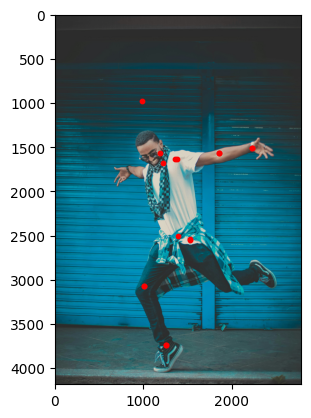

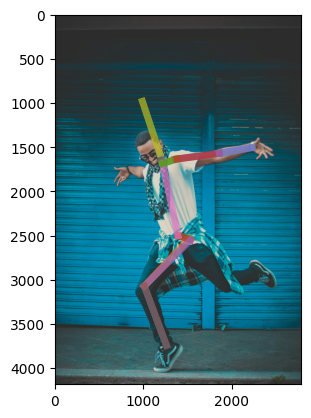

In [179]:
import os

test_image = os.path.join(PROJECT_PATH, 'test_image.jpg')

image, keypoints = predict(model, test_image)
draw_keypoints_on_image(image, keypoints)
draw_skeleton_on_image(image, keypoints)

# **24. 행동 스티커 만들기 [프로젝트]**

## **24-1. Project: 모델 바꿔보기**

### **라이브러리 버전 확인**
---

프로젝트에 사용할 주요 라이브러리 버전을 확인해봅니다.

In [180]:
import torch
import numpy as np
import PIL
import ray

print(torch.__version__)
print(np.__version__)
print(PIL.__version__)
print(ray.__version__)

2.11.0+cu128
2.1.3
11.3.0
2.58.0


### **simplebaseline 모델로 변경해 봅시다**
---

지금까지 우리는 StackedHourglass Network 기반으로 학습을 진행해 왔습니다.<br>
<br>
그러나 지난 시간에 살펴본 것처럼 Simplebaseline 모델은 이보다 훨씬 간단한 모델 구조에도 불구하고 더욱 좋은 성능을 보여주었던 바 있습니다.<br>
<br>
실제로도 그런 성능을 얻을 수 있을지 확인해 보겠습니다.

### **STEP 1 : simplebaseline 모델 완성하기**
---

`simplebaseline.py` 파일과 이전에 살펴본 Simplebaseline 내용을 참고하여 모델을 완성합니다.

In [181]:
import torch
import torch.nn as nn
import torchvision.models as models

class Simplebaseline(nn.Module):
    def __init__(self, num_heatmap=16):
        super(Simplebaseline, self).__init__()

        # ResNet50 백본 로드 (ImageNet 사전 학습 가중치 사용)
        self.resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

        # ResNet의 마지막 레이어 제거 (평균 풀링 및 FC 레이어)
        # ResNet50의 Conv 레이어 출력은 (batch_size, 2048, 8, 8) 입니다.
        self.resnet_features = nn.Sequential(*list(self.resnet.children())[:-2])

        # _make_deconv_layer와 동일한 구조의 디컨볼루션 레이어
        # filters=256, kernel_size=4, strides=2, padding='same'
        self.deconv_layers = self._make_deconv_layer(num_deconv_layers=3, in_channels=2048)

        # 최종 히트맵 출력 레이어
        self.final_layer = nn.Conv2d(in_channels=256, out_channels=num_heatmap, kernel_size=1, stride=1, padding=0)

    def _make_deconv_layer(self, num_deconv_layers, in_channels):
        layers = []
        current_in_channels = in_channels
        for _ in range(num_deconv_layers):
            layers.append(nn.ConvTranspose2d(
                in_channels=current_in_channels,
                out_channels=256,
                kernel_size=4,
                stride=2,
                padding=1, # 'same' padding with stride 2 and kernel 4 becomes padding 1
                bias=False
            ))
            layers.append(nn.BatchNorm2d(256))
            layers.append(nn.ReLU(inplace=True))
            current_in_channels = 256
        return nn.Sequential(*layers)

    def forward(self, x):
        # ResNet 백본을 통해 특징 추출
        x = self.resnet_features(x)

        # 디컨볼루션 레이어를 통해 업샘플링
        x = self.deconv_layers(x)

        # 최종 히트맵 생성
        x = self.final_layer(x)
        return [x] # Trainer 클래스가 리스트 형태의 출력을 기대하므로 리스트로 감쌉니다.

print('Simplebaseline model defined.')

Simplebaseline model defined.


In [188]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# 1. Stacked Hourglass Network
hg_model = StackedHourglassNetwork(
    IMAGE_SHAPE,
    num_stack=CONFIG['hourglass_num_stack'],
    num_residual=CONFIG['hourglass_num_residual'],
    num_heatmap=CONFIG['num_heatmap']
)
print("========== StackedHourglassNetwork Structure ==========")
print(hg_model)
print(f"\n-> Hourglass Trainable Parameters: {count_parameters(hg_model):,}\n")

========== StackedHourglassNetwork Structure ==========
StackedHourglassNetwork(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.9, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (bottleneck1): BottleneckBlock(
    (downsample_conv): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.9, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.9, affine=True, track_running_stats=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.9, affine=True, track_running_stats=True)
    (conv3): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
  )
  (pool): MaxPool2d(kernel_size=2, stride=2

In [189]:
# 2. Simplebaseline
sb_model = Simplebaseline(num_heatmap=CONFIG['num_heatmap'])
print("========== Simplebaseline Structure ==========")
print(sb_model)
print(f"\n-> Simplebaseline Trainable Parameters: {count_parameters(sb_model):,}")

========== Simplebaseline Structure ==========
Simplebaseline(
  (resnet): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inpla

### **STEP 2 : simplebaseline 모델로 변경하여 훈련하기**
---

StackedHourglass를 학습시킨 코드의 모델 선언 부분을 simplebaseline 모델로 변경한 후 다시 학습을 진행합니다.

In [186]:
%%time
import os
import json
import time

# 공통 학습 파라미터 설정
TRAIN_JSON = os.path.join('./aiffel/mpii/mpii_human_pose_v1_u12_2', 'train.json')
VAL_JSON = os.path.join('./aiffel/mpii/mpii_human_pose_v1_u12_2', 'validation.json')
IMAGE_DIR = os.path.join('./aiffel/mpii', 'images')

epochs_to_train = CONFIG['epochs']
batch_size = CONFIG['batch_size']
num_heatmap = CONFIG['num_heatmap']
learning_rate = CONFIG['learning_rate']

DRIVE_SAVE_PATH = '/content/drive/MyDrive/aiffel/mpii/ablation'
os.makedirs(DRIVE_SAVE_PATH, exist_ok=True)

# --- 1. StackedHourglassNetwork 로드/학습 ---
print("\n===== [1] StackedHourglassNetwork =====")
HG_HISTORY_FILE = os.path.join(DRIVE_SAVE_PATH, 'history.json') # 위 셀과 동일한 이름 사용
HG_MODEL_FILE = os.path.join(DRIVE_SAVE_PATH, 'best_hourglass_model.pt')

if os.path.exists(HG_HISTORY_FILE) and os.path.exists(HG_MODEL_FILE):
    print(f"구글 드라이브({DRIVE_SAVE_PATH})에 학습 기록과 모델이 존재합니다.")
    print("학습을 건너뛰고 결과를 불러옵니다.")
    with open(HG_HISTORY_FILE, 'r') as f:
        history = json.load(f)
    train_losses_hourglass = history['train_loss']
    val_losses_hourglass = history['val_loss']
    epoch_durations_hourglass = history.get('epoch_duration', []) # 기존에 없으면 빈 리스트
    best_hourglass_model_file = HG_MODEL_FILE
else:
    print("구글 드라이브에 학습 기록이 없습니다. 새로운 학습을 시작합니다.")
    start_time = time.time()
    best_model_file, train_losses_hourglass, val_losses_hourglass, epoch_durations_hourglass = train(
        epochs_to_train, learning_rate, num_heatmap, batch_size, TRAIN_JSON, VAL_JSON, IMAGE_DIR, model_type='hourglass'
    )
    end_time = time.time()
    print(f"총 학습 소요 시간: {(end_time - start_time) / 60:.2f} 분")
    os.system(f"cp {best_model_file} {HG_MODEL_FILE}")
    with open(HG_HISTORY_FILE, 'w') as f:
        json.dump({'train_loss': train_losses_hourglass, 'val_loss': val_losses_hourglass, 'epoch_duration': epoch_durations_hourglass}, f)
    print(f"학습 결과 및 모델이 구글 드라이브에 성공적으로 저장되었습니다.")
    best_hourglass_model_file = HG_MODEL_FILE


# --- 2. Simplebaseline 로드/학습 ---
print("\n===== [2] Simplebaseline =====")
SB_HISTORY_FILE = os.path.join(DRIVE_SAVE_PATH, 'history_simplebaseline.json')
SB_MODEL_FILE = os.path.join(DRIVE_SAVE_PATH, 'best_simplebaseline_model.pt')

if os.path.exists(SB_HISTORY_FILE) and os.path.exists(SB_MODEL_FILE):
    print(f"구글 드라이브({DRIVE_SAVE_PATH})에 학습 기록과 모델이 존재합니다.")
    print("학습을 건너뛰고 결과를 불러옵니다.")
    with open(SB_HISTORY_FILE, 'r') as f:
        history = json.load(f)
    train_losses_simplebaseline = history['train_loss']
    val_losses_simplebaseline = history['val_loss']
    epoch_durations_simplebaseline = history.get('epoch_duration', []) # 기존에 없으면 빈 리스트
    best_simplebaseline_model_file = SB_MODEL_FILE
else:
    print("구글 드라이브에 학습 기록이 없습니다. 새로운 학습을 시작합니다.")
    start_time = time.time()
    best_model_file, train_losses_simplebaseline, val_losses_simplebaseline, epoch_durations_simplebaseline = train(
        epochs_to_train, learning_rate, num_heatmap, batch_size, TRAIN_JSON, VAL_JSON, IMAGE_DIR, model_type='simplebaseline'
    )
    end_time = time.time()
    print(f"총 학습 소요 시간: {(end_time - start_time) / 60:.2f} 분")
    os.system(f"cp {best_model_file} {SB_MODEL_FILE}")
    with open(SB_HISTORY_FILE, 'w') as f:
        json.dump({'train_loss': train_losses_simplebaseline, 'val_loss': val_losses_simplebaseline, 'epoch_duration': epoch_durations_simplebaseline}, f)
    print(f"학습 결과 및 모델이 구글 드라이브에 성공적으로 저장되었습니다.")
    best_simplebaseline_model_file = SB_MODEL_FILE



===== [1] StackedHourglassNetwork =====
구글 드라이브(/content/drive/MyDrive/aiffel/mpii/ablation)에 학습 기록과 모델이 존재합니다.
학습을 건너뛰고 결과를 불러옵니다.

===== [2] Simplebaseline =====
구글 드라이브(/content/drive/MyDrive/aiffel/mpii/ablation)에 학습 기록과 모델이 존재합니다.
학습을 건너뛰고 결과를 불러옵니다.
CPU times: user 1.59 ms, sys: 0 ns, total: 1.59 ms
Wall time: 4.55 ms


### **STEP 3 : 두 모델의 비교**
---

실습에서 다룬 StackedHourglass Network와 Simplebaseline 모델을 둘 다 동일한 Epoch 수만큼 학습하여 그 결과를 비교해 봅니다.<br>
<br>
- Pose Estimation 결과 시각화 (정성적 비교)
- 학습 진행 경과 (loss 감소 현황)<br><br>

가급적 두 모델 모두 최소 3epoch 이상, (5epoch 이상 권장)을 학습하기 바랍니다.

#### Pose Estimation 결과 시각화 (정성적 비교)

두 모델의 학습이 완료되면, 동일한 테스트 이미지에 대해 Pose Estimation 결과를 시각화하여 정성적으로 비교해 봅시다.

먼저, `StackedHourglassNetwork`의 결과를 확인합니다.


===== StackedHourglassNetwork Prediction ====
Loaded StackedHourglassNetwork weights from: /content/drive/MyDrive/aiffel/mpii/ablation/best_hourglass_model.pt
StackedHourglassNetwork - Keypoints Visualization:


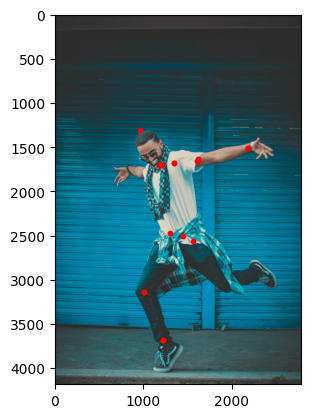

StackedHourglassNetwork - Skeleton Visualization:


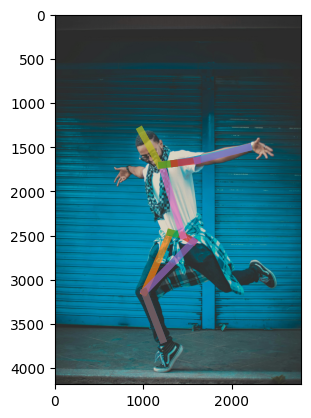


===== Simplebaseline Prediction ====
Loaded Simplebaseline weights from: /content/drive/MyDrive/aiffel/mpii/ablation/best_simplebaseline_model.pt
Simplebaseline - Keypoints Visualization:


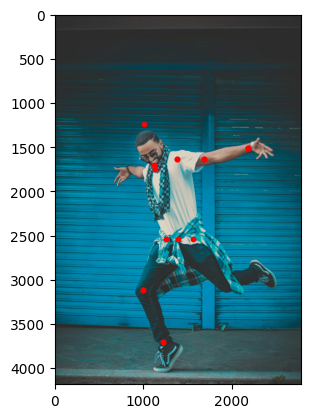

Simplebaseline - Skeleton Visualization:


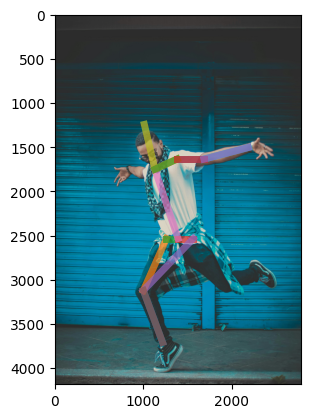

In [183]:
import os

# 테스트 이미지 경로
test_image_path = os.path.join(PROJECT_PATH, 'test_image.jpg')

# --- StackedHourglassNetwork 결과 ---
print("\n===== StackedHourglassNetwork Prediction ====")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
hourglass_model = StackedHourglassNetwork(IMAGE_SHAPE, num_stack=4, num_residual=1, num_heatmap=num_heatmap)
hourglass_model.to(device)

# 학습된 가중치 로드 (best_hourglass_model_file 변수가 설정되어 있어야 합니다.)
# 만약 학습을 건너뛰었다면, 미리 다운로드된 가중치를 사용하거나 다른 가중치 경로를 지정해야 합니다.
if 'best_hourglass_model_file' in locals() and best_hourglass_model_file:
    checkpoint = torch.load(best_hourglass_model_file, map_location=device)
    hourglass_model.load_state_dict(checkpoint)
    print(f"Loaded StackedHourglassNetwork weights from: {best_hourglass_model_file}")
else:
    print("StackedHourglassNetwork의 학습된 모델 가중치를 찾을 수 없습니다. 예시 가중치를 로드합니다.")
    # 미리 다운로드된 가중치 로드 (실습 코드의 WEIGHTS_PATH 변수 활용)
    # WEIGHTS_PATH가 없으면 gdown으로 다운로드하는 로직을 추가해야 함
    if not os.path.exists(WEIGHTS_PATH):
        import gdown
        file_id = "1-F6ztKRSL7Lp0kVT7nPuSIfEpBWz1abZ"
        output_path = "model-epoch-2-loss-1.2050.pt"
        gdown.download(f"https://drive.google.com/uc?id={file_id}", output_path, quiet=False)
        ! mv model-epoch-2-loss-1.2050.pt ./aiffel/mpii/models
    WEIGHTS_PATH = os.path.join(PROJECT_PATH, 'models', 'model-epoch-2-loss-1.2050.pt')
    checkpoint = torch.load(WEIGHTS_PATH, map_location=device)
    hourglass_model.load_state_dict(checkpoint)
    print(f"Loaded example StackedHourglassNetwork weights from: {WEIGHTS_PATH}")

image_hg, keypoints_hg = predict(hourglass_model, test_image_path)

print("StackedHourglassNetwork - Keypoints Visualization:")
draw_keypoints_on_image(image_hg, keypoints_hg)
print("StackedHourglassNetwork - Skeleton Visualization:")
draw_skeleton_on_image(image_hg, keypoints_hg)


# --- Simplebaseline 결과 ---
print("\n===== Simplebaseline Prediction ====")

simplebaseline_model = Simplebaseline(num_heatmap=num_heatmap)
simplebaseline_model.to(device)

# 학습된 가중치 로드
if 'best_simplebaseline_model_file' in locals() and best_simplebaseline_model_file:
    checkpoint = torch.load(best_simplebaseline_model_file, map_location=device)
    simplebaseline_model.load_state_dict(checkpoint)
    print(f"Loaded Simplebaseline weights from: {best_simplebaseline_model_file}")
else:
    print("Simplebaseline의 학습된 모델 가중치를 찾을 수 없습니다. 모델을 다시 학습시켜주세요.")


image_sb, keypoints_sb = predict(simplebaseline_model, test_image_path)

print("Simplebaseline - Keypoints Visualization:")
draw_keypoints_on_image(image_sb, keypoints_sb)
print("Simplebaseline - Skeleton Visualization:")
draw_skeleton_on_image(image_sb, keypoints_sb)

#### 학습 진행 경과 (loss 감소 현황)

두 모델의 학습 손실(Loss) 변화를 비교하여 학습 진행 경과를 분석합니다.

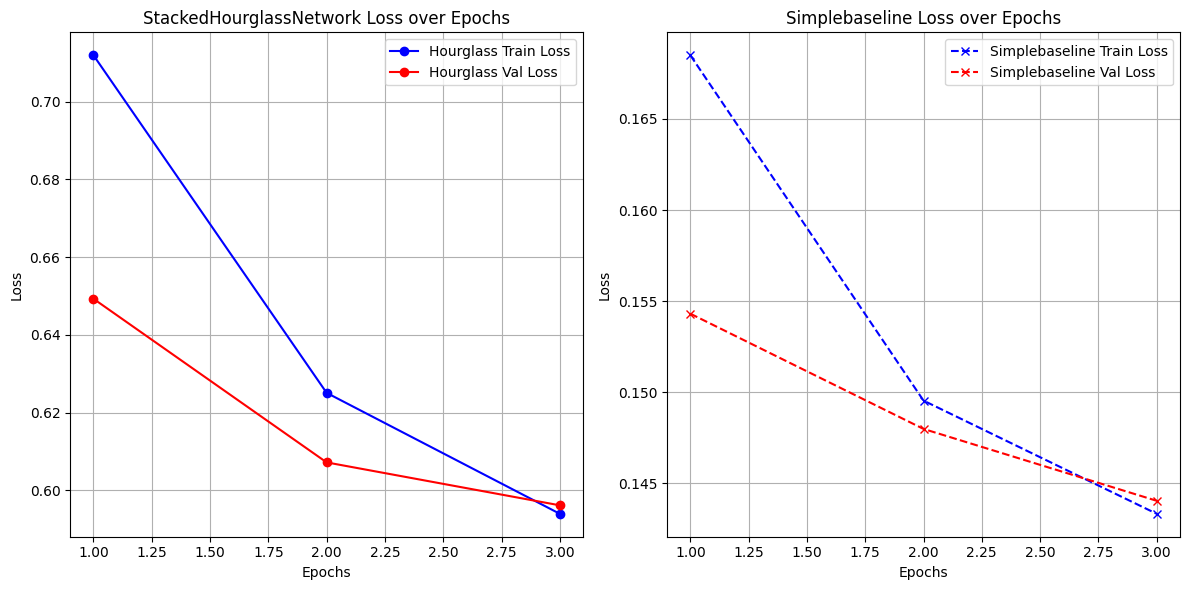

In [184]:
import matplotlib.pyplot as plt

epochs = range(1, CONFIG['epochs'] + 1)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
if 'train_losses_hourglass' in globals() and 'val_losses_hourglass' in globals():
    plt.plot(epochs, train_losses_hourglass, 'b-o', label='Hourglass Train Loss')
    plt.plot(epochs, val_losses_hourglass, 'r-o', label='Hourglass Val Loss')
else:
    plt.text(0.5, 0.5, 'Hourglass training skipped', ha='center', va='center')
plt.title('StackedHourglassNetwork Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
if 'train_losses_simplebaseline' in globals() and 'val_losses_simplebaseline' in globals():
    plt.plot(epochs, train_losses_simplebaseline, 'b--x', label='Simplebaseline Train Loss')
    plt.plot(epochs, val_losses_simplebaseline, 'r--x', label='Simplebaseline Val Loss')
else:
    plt.text(0.5, 0.5, 'Simplebaseline training skipped', ha='center', va='center')
plt.title('Simplebaseline Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

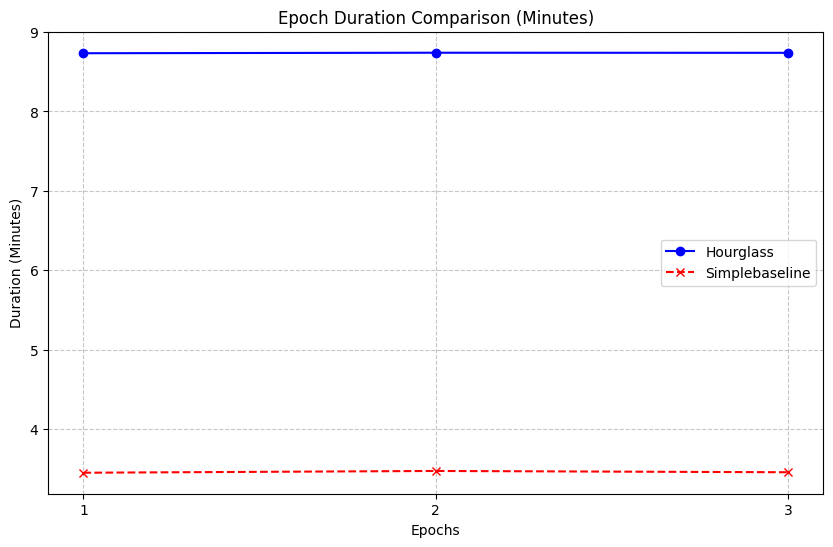

평균 1에폭 소요 시간 (Hourglass): 8.74 분
평균 1에폭 소요 시간 (Simplebaseline): 3.46 분


In [185]:
import matplotlib.pyplot as plt
import numpy as np

if 'epoch_durations_hourglass' in globals() and 'epoch_durations_simplebaseline' in globals():
    if len(epoch_durations_hourglass) > 0 and len(epoch_durations_simplebaseline) > 0:
        epochs = range(1, len(epoch_durations_hourglass) + 1)

        # 초 단위를 분 단위로 변환하여 시각화
        hg_durations_min = [t / 60 for t in epoch_durations_hourglass]
        sb_durations_min = [t / 60 for t in epoch_durations_simplebaseline]

        plt.figure(figsize=(10, 6))
        plt.plot(epochs, hg_durations_min, 'b-o', label='Hourglass')
        plt.plot(epochs, sb_durations_min, 'r--x', label='Simplebaseline')

        plt.title('Epoch Duration Comparison (Minutes)')
        plt.xlabel('Epochs')
        plt.ylabel('Duration (Minutes)')
        plt.xticks(epochs)
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.show()

        avg_hg = np.mean(hg_durations_min)
        avg_sb = np.mean(sb_durations_min)
        print(f"평균 1에폭 소요 시간 (Hourglass): {avg_hg:.2f} 분")
        print(f"평균 1에폭 소요 시간 (Simplebaseline): {avg_sb:.2f} 분")
    else:
        print("에폭 소요 시간 데이터가 비어있습니다. 이전 셀에서 학습을 정상적으로 완료했는지 확인해주세요.")
else:
    print("에폭 소요 시간 변수를 찾을 수 없습니다. 학습 진행 셀을 먼저 실행해주세요.")

## **24-2. 프로젝트 제출**

### 루브릭

아래의 기준을 바탕으로 프로젝트를 평가합니다.<br>
<br>

|평가문항|상세기준|
|-|-|
|<br>1. tfrecord를 활용한 데이터셋 구성과 전처리를 통해 프로젝트<br> 베이스라인 구성을 확인하였다.<br><br>|	MPII 데이터셋을 기반으로 1epoch에 30분 이내에 학습가능한<br> 베이스라인을 구축하였다.|
|<br>2. simplebaseline 모델을 정상적으로 구현하였다.<br><br>|simplebaseline 모델을 구현하여 실습코드의 모델을 대체하여<br> 정상적으로 학습이 진행되었다.|
|<br>3. Hourglass 모델과 simplebaseline 모델을 비교분석한 결과를<br> 체계적으로 정리하였다.<br><br>|두 모델의 pose estimation 테스트결과 이미지 및 학습진행상황 등을<br> 체계적으로 비교분석하였다.|

### 프로젝트 제출

프로젝트 제출 방법 안내